# Notebook: `04_model_training_and_evaluation.ipynb`

### Objective & Scope

Notebook này thực thi giai đoạn kiểm chứng thực nghiệm cốt lõi của đề xuất nghiên cứu. Sử dụng ma trận đặc trưng đa chiều sạch `uk_electricity_features.csv` được bàn giao từ `03_feature_engineering_and_selection.ipynb`, ta huấn luyện, tinh chỉnh và đối chiếu một cách hệ thống sáu kiến trúc mô hình khác nhau hai đường cơ sở mùa vụ ngây thơ **SNaive Daily** ($\hat{Y}_t = Y_{t-48}$) và **SNaive Weekly** ($\hat{Y}_t = Y_{t-336}$), cùng với Linear Regression, Random Forest, XGBoost và LightGBM để dự báo **Nhu cầu điện năng quốc gia (National Demand, ND)** của lưới điện Vương quốc Anh



###Thiết lập môi trường

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = 'bold'

###Hàm hỗ trợ (Helper Functions)

Ba hàm hỗ trợ dưới đây được kế thừa trực tiếp từ mục "0.1 Helper Function" của `Hourly_Energy_Consumption.ipynb`, có điều chỉnh cho phù hợp với một chuỗi thời gian quốc gia duy nhất:

* `ml_error()`: tính bốn chỉ số R2, MAE, RMSE và MAPE cho một tập dự báo.
* `mean_percentage_error()`: tính sai số phần trăm có dấu (MPE), dùng để chẩn đoán thiên lệch hệ thống (overestimate hay underestimate) của mô hình cuối cùng ở phần 8.2.
* `cross_validation()`: thay vì vòng lặp qua nhiều công ty điện lực như notebook tham chiếu, hàm này thực hiện Cross Validation dạng cửa sổ mở rộng theo thời gian (expanding window) trên một chuỗi thời gian liên tục duy nhất, chia `X_training` thành `kfold` cặp huấn luyện/kiểm định liên tiếp lùi dần về quá khứ, mỗi cặp cách nhau `validation_days` ngày.

In [2]:
def mean_percentage_error(y, yhat):
    return np.mean((y - yhat) / y)

def mean_absolute_percentage_error(y, yhat):
    return np.mean(np.abs((y - yhat) / y)) * 100

def ml_error(model_name, y, yhat):
    r2 = r2_score(y, yhat)
    mae = mean_absolute_error(y, yhat)
    rmse = np.sqrt(mean_squared_error(y, yhat))
    mape = mean_absolute_percentage_error(y, yhat)
    return pd.DataFrame({"Model Name": model_name, "R2": r2, "MAE": mae,
                          "RMSE": rmse, "MAPE (%)": mape}, index=[0])

def cross_validation(X_training, kfold, model_name, model, feature_cols, target_col="ND",
                       validation_days=120, verbose=False):
    r2_list, mae_list, rmse_list, mape_list = [], [], [], []
    for k in reversed(range(1, kfold + 1)):
        if verbose:
            print(f"\nKFold Number: {k}")
        validation_start = X_training.index.max() - pd.Timedelta(days=k * validation_days)
        validation_end = X_training.index.max() - pd.Timedelta(days=(k - 1) * validation_days)

        training_fold = X_training[X_training.index < validation_start]
        validation_fold = X_training[(X_training.index >= validation_start) & (X_training.index <= validation_end)]

        xtraining_fold, ytraining_fold = training_fold[feature_cols], training_fold[target_col]
        xvalidation_fold, yvalidation_fold = validation_fold[feature_cols], validation_fold[target_col]

        if verbose:
            print(f"  Train: {xtraining_fold.shape[0]:,} dòng | Validation: {xvalidation_fold.shape[0]:,} dòng")

        m = model.fit(xtraining_fold, ytraining_fold)
        yhat_fold = m.predict(xvalidation_fold)
        m_result = ml_error(model_name, yvalidation_fold, yhat_fold)

        r2_list.append(m_result["R2"][0])
        mae_list.append(m_result["MAE"][0])
        rmse_list.append(m_result["RMSE"][0])
        mape_list.append(m_result["MAPE (%)"][0])

    return pd.DataFrame({
        "Model Name": model_name,
        "R2 CV": f"{np.mean(r2_list):.4f} +/- {np.std(r2_list):.4f}",
        "MAE CV": f"{np.mean(mae_list):.2f} +/- {np.std(mae_list):.2f}",
        "RMSE CV": f"{np.mean(rmse_list):.2f} +/- {np.std(rmse_list):.2f}",
        "MAPE CV (%)": f"{np.mean(mape_list):.2f} +/- {np.std(mape_list):.2f}",
    }, index=[0])

results = []
results_cv = []
predictions = {}

### Feature Matrix Ingestion

Ta nạp ma trận đặc trưng dày đặc chứa các đặc trưng trễ tự hồi quy ($H \in \{1,2,12,24,36,48,336\}$), các thống kê trượt, và các biến lượng giác tuần hoàn đã được xây dựng và kiểm định ở notebook 03.

In [3]:
df = pd.read_csv("uk_electricity_features.csv")
df["DATETIME"] = pd.to_datetime(df["DATETIME"])
df = df.set_index("DATETIME").sort_index()

so_nan = df.isna().sum().sum()
print(f"Kích thước ma trận đặc trưng: {df.shape[0]:,} dòng x {df.shape[1]} cột")
print(f"Giai đoạn: {df.index.min()} đến {df.index.max()}")
print(f"Tổng số giá trị NaN: {so_nan:,}")

if so_nan > 0:
    df = df.dropna()
    print(f"Đã loại bỏ NaN, làm sạch một lần duy nhất ngay tại bước nạp dữ liệu. Kích thước sau khi làm sạch: {df.shape[0]:,} dòng.")
else:
    print("Không có NaN — ma trận đặc trưng đã được bàn giao sạch từ notebook 03, không cần dropna() ở bất kỳ bước huấn luyện mô hình nào phía sau.")

df.head()

Kích thước ma trận đặc trưng: 104,880 dòng x 52 cột
Giai đoạn: 2020-01-08 00:00:00 đến 2025-12-31 23:30:00
Tổng số giá trị NaN: 0
Không có NaN — ma trận đặc trưng đã được bàn giao sạch từ notebook 03, không cần dropna() ở bất kỳ bước huấn luyện mô hình nào phía sau.


,ND,TSD,ENGLAND_WALES_DEMAND,ND_LAG_1,ENGLAND_WALES_DEMAND_LAG_1,TSD_LAG_1,ND_LAG_2,ENGLAND_WALES_DEMAND_LAG_2,TSD_LAG_2,ND_LAG_48,ENGLAND_WALES_DEMAND_LAG_48,ENGLAND_WALES_DEMAND_LAG_336,ND_LAG_336,TSD_LAG_48,TSD_LAG_336,ND_ROLL_MEAN_8,ND_ROLL_MEAN_48,ND_ROLL_MEAN_24,SETTLEMENT_PERIOD,EMBEDDED_SOLAR_CAPACITY,ND_ROLL_STD_48,PUMP_STORAGE_PUMPING,ENGLAND_WALES_DEMAND_LAG_12,SOLAR_ROLL_MEAN_8,ND_LAG_12,PERIOD_SIN,TSD_LAG_12,SOLAR_ROLL_MEAN_48,ENGLAND_WALES_DEMAND_LAG_36,ND_LAG_36,EMBEDDED_SOLAR_GENERATION,TSD_LAG_36,PERIOD_COS,NEMO_FLOW,BRITNED_FLOW,IFA_FLOW,TSD_LAG_24,ND_LAG_24,ND_ROLL_STD_24,NSL_FLOW,ENGLAND_WALES_DEMAND_LAG_24,EMBEDDED_WIND_CAPACITY,ND_ROLL_STD_8,SOLAR_ROLL_MEAN_24,MOYLE_FLOW,IFA2_FLOW,ELECLINK_FLOW,EMBEDDED_WIND_GENERATION,DOW_SIN,EAST_WEST_FLOW,IS_WEEKEND,VIKING_FLOW
DATETIME,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-01-08 00:00:00,"22,751.0000","25,625.0000","21,366.0000","23,133.0000","21,710.0000","25,771.0000","24,399.0000","22,844.0000","26,364.0000","25,424.0000","23,665.0000","23,821.0000","26,340.0000","26,034.0000","27,153.0000","29,365.3750","32,668.0208","35,578.7083",1,"13,042.0000","6,349.8636",520.0000,"37,684.0000",0.0000,"40,529.0000",0.1305,"41,136.0000",149.4583,"26,109.0000","27,669.0000",0.0000,"28,897.0000",0.9914,-681.0000,355.0000,-672.0000,"38,603.0000","37,467.0000","5,329.7418",0.0000,"34,853.0000","6,465.0000","4,626.6129",144.1667,-334.0000,0.0000,0.0000,"4,496.0000",0.9749,-67.0000,0,0.0000
2020-01-08 00:30:00,"23,123.0000","25,520.0000","21,795.0000","22,751.0000","21,366.0000","25,625.0000","23,133.0000","21,710.0000","25,771.0000","25,967.0000","24,271.0000","24,393.0000","26,921.0000","26,582.0000","27,684.0000","27,727.3750","32,612.3333","34,965.5417",2,"13,042.0000","6,426.0088",26.0000,"36,763.0000",0.0000,"39,646.0000",0.2588,"40,251.0000",149.4583,"28,795.0000","30,571.0000",0.0000,"31,837.0000",0.9659,-681.0000,339.0000,-673.0000,"38,435.0000","37,283.0000","5,917.1912",0.0000,"34,658.0000","6,465.0000","4,309.6105",108.2917,-395.0000,0.0000,0.0000,"4,331.0000",0.9749,-22.0000,0,0.0000
2020-01-08 01:00:00,"22,990.0000","25,742.0000","21,641.0000","23,123.0000","21,795.0000","25,520.0000","22,751.0000","21,366.0000","25,625.0000","25,767.0000","24,160.0000","24,085.0000","26,569.0000","26,674.0000","27,240.0000","26,350.0000","32,553.0833","34,375.5417",3,"13,042.0000","6,501.2554",255.0000,"35,864.0000",0.0000,"38,666.0000",0.3827,"39,277.0000",149.4583,"31,770.0000","33,850.0000",0.0000,"34,939.0000",0.9239,-625.0000,409.0000,-673.0000,"38,877.0000","37,423.0000","6,365.0652",0.0000,"34,820.0000","6,465.0000","3,681.7069",72.2083,-455.0000,0.0000,0.0000,"4,304.0000",0.9749,-144.0000,0,0.0000
2020-01-08 01:30:00,"22,427.0000","25,516.0000","21,134.0000","22,990.0000","21,641.0000","25,742.0000","23,123.0000","21,795.0000","25,520.0000","25,170.0000","23,645.0000","23,350.0000","25,754.0000","26,386.0000","26,435.0000","25,158.0000","32,495.2292","33,774.1667",4,"13,042.0000","6,574.8685",514.0000,"34,668.0000",0.0000,"37,276.0000",0.5000,"37,886.0000",149.4583,"33,371.0000","35,608.0000",0.0000,"36,772.0000",0.8660,-619.0000,412.0000,-672.0000,"38,765.0000","37,299.0000","6,735.6520",0.0000,"34,699.0000","6,465.0000","2,845.1580",47.5000,-456.0000,0.0000,0.0000,"4,239.0000",0.9749,-228.0000,0,0.0000
2020-01-08 02:00:00,"22,167.0000","25,331.0000","20,863.0000","22,427.0000","21,134.0000","25,516.0000","22,990.0000","21,641.0000","25,742.0000","24,535.0000","23,083.0000","22,788.0000","25,075.0000","26,387.0000","25,824.0000","24,159.7500","32,438.0833","33,154.5000",5,"13,042.0000","6,651.3663",915.0000,"33,386.0000",0.0000,"35,855.0000",0.6088,"36,467.0000",149.4583,"34,039.0000","36,396.0000",0.0000,"37,600.0000",0.7934,-138.0000,142.0000,-678.0000,"38,509.0000","37,240.0000","7,072.9283",0.0000,"34,647.0000","6,465.0000","2,019.0444",27.4167,-456.0000,0.0000,0.0000,"4,056.0000",0.9749,-377.0000,0,0.0000


## 1. Chronological Data Slicing (Train / Valid / Test Split)

Theo đúng kiến trúc quy trình của *Step 7 của Hourly Energy Consumption*, ta phân chia toàn bộ khung thời gian 6 năm một cách tuần tự nghiêm ngặt:

* **Tập huấn luyện**: 4 năm đầu tiên (2020 đến 2023) ➔ dùng để học các hệ số thống kê nền tảng và huấn luyện "Single Performance" của từng mô hình.
* **Tập kiểm định**: năm 2024 ➔ dùng để tinh chỉnh siêu tham số và thực thi dừng sớm (early stopping) của XGBoost và LightGBM.
* **Tập kiểm tra**: năm 2025 ➔ giữ lại hoàn toàn như một chuẩn đối chiếu ngoài mẫu, không tham gia vào bất kỳ bước Cross Validation hay Hyperparameter Fine Tuning nào.

Ngoài ba tập trên, ta còn định nghĩa `X_training` gồm toàn bộ dữ liệu từ 2020 đến hết 2024 (Train cộng Valid), là đầu vào riêng cho hàm `cross_validation()` ở các phần 6 và 7, đúng vai trò của biến `X_training` trong notebook tham chiếu.

In [4]:
BIEN_MUC_TIEU = "ND"
CAC_COT_MUC_TIEU = ["ND", "TSD", "ENGLAND_WALES_DEMAND"]
CAC_COT_DAC_TRUNG = [c for c in df.columns if c not in CAC_COT_MUC_TIEU]

train = df.loc[:"2023-12-31 23:30:00"]
valid = df.loc["2024-01-01":"2024-12-31 23:30:00"]
test = df.loc["2025-01-01":"2025-12-31 23:30:00"]

# X_training: toàn bộ dữ liệu trước năm kiểm tra cuối cùng (2020-2024), dùng riêng cho Cross Validation
X_training = df.loc[:"2024-12-31 23:30:00"]

print(f"Tập huấn luyện (2020-2023): {train.shape[0]:,} dòng")
print(f"Tập kiểm định   (2024):      {valid.shape[0]:,} dòng")
print(f"Tập kiểm tra    (2025):      {test.shape[0]:,} dòng  (giữ lại hoàn toàn, không dùng trong Cross Validation)")
print(f"X_training cho Cross Validation (2020-2024): {X_training.shape[0]:,} dòng")

X_train, y_train = train[CAC_COT_DAC_TRUNG], train[BIEN_MUC_TIEU]
X_valid, y_valid = valid[CAC_COT_DAC_TRUNG], valid[BIEN_MUC_TIEU]
X_test, y_test = test[CAC_COT_DAC_TRUNG], test[BIEN_MUC_TIEU]

Tập huấn luyện (2020-2023): 69,792 dòng
Tập kiểm định   (2024):      17,568 dòng
Tập kiểm tra    (2025):      17,520 dòng  (giữ lại hoàn toàn, không dùng trong Cross Validation)
X_training cho Cross Validation (2020-2024): 87,360 dòng


**Nhận xét**

Tổng ba tập huấn luyện, kiểm định và kiểm tra vẫn đúng bằng 104.880 dòng của ma trận gốc. Điểm khác biệt so với thiết kế ở notebook trước là sự xuất hiện của X_training, gộp Train và Valid lại thành một chuỗi liên tục 2020 đến 2024 dùng riêng cho Cross Validation ở mục 2.4.2 và mục 3, trong khi Test năm 2025 được niêm phong hoàn toàn, chỉ được mở ra đúng một lần duy nhất ở mục 3.2 để đánh giá Final Model và ở mục 4 để dịch nghĩa sai số, mô phỏng chính xác cách notebook tham chiếu tách bạch X_train dùng cho Cross Validation khỏi X_test dùng làm chuẩn đối chiếu cuối cùng.

## 2. Baseline Estimators Execution

### 2.1 SNaive Daily

Đường cơ sở mùa vụ ngây thơ thứ nhất, công thức $\hat{Y}_t = Y_{t-48}$: dự báo nhu cầu tại thời điểm hiện tại bằng đúng giá trị quan trắc được tại cùng chu kỳ quyết toán của đúng một ngày trước đó. Vì cột `ND_LAG_48` đã được xây dựng sẵn ở notebook 03, dự báo SNaive Daily chỉ đơn giản là đọc lại giá trị của cột này trên tập kiểm tra, không cần huấn luyện, không có tham số cần ước lượng.


In [5]:
yhat_snaive_daily = test["ND_LAG_48"]

snaive_daily_result = ml_error("SNaive Daily", y_test, yhat_snaive_daily)
results.append(snaive_daily_result)
predictions["SNaive Daily"] = yhat_snaive_daily
snaive_daily_result

,Model Name,R2,MAE,RMSE,MAPE (%)
0,SNaive Daily,0.8257,"1,849.6641","2,577.1952",7.3703


### 2.2 SNaive Weekly

Đường cơ sở mùa vụ ngây thơ thứ hai, công thức $\hat{Y}_t = Y_{t-336}$: dự báo nhu cầu tại thời điểm hiện tại bằng đúng giá trị quan trắc được tại cùng chu kỳ quyết toán của đúng bảy ngày trước đó, sử dụng cột `ND_LAG_336` đã có sẵn từ notebook 03. Đại diện cho giả định nhu cầu điện hôm nay giống hệt đúng thứ này của tuần trước, ví dụ sáng Thứ Hai đối chiếu với sáng Thứ Hai tuần trước thay vì với ngày Chủ Nhật nghỉ ngơi liền trước.


In [6]:
yhat_snaive_weekly = test["ND_LAG_336"]

snaive_weekly_result = ml_error("SNaive Weekly", y_test, yhat_snaive_weekly)
results.append(snaive_weekly_result)
predictions["SNaive Weekly"] = yhat_snaive_weekly
snaive_weekly_result


,Model Name,R2,MAE,RMSE,MAPE (%)
0,SNaive Weekly,0.7764,"2,177.7065","2,918.8894",8.4360


Vì cả SNaive Daily lẫn SNaive Weekly đều là phép ngoại suy tất định không có tham số cần ước lượng chỉ là phép tra cứu lại đúng một cột đã có sẵn trong ma trận đặc trưng (`ND_LAG_48` và `ND_LAG_336`) , hai đường cơ sở này **không cần xuất ra `.pkl`**: không có gì để lưu ngoài chính công thức $\hat{Y}_t = Y_{t-48}$ và $\hat{Y}_t = Y_{t-336}$ đã ghi ở trên. Để dự báo lại trong tương lai, chỉ cần dịch chuyển (shift) chuỗi ND đúng 48 hoặc 336 chu kỳ.


### 2.3 Linear Regression Model

Mô hình hồi quy tuyến tính đa biến, huấn luyện trực tiếp trên toàn bộ 49 đặc trưng, đóng vai trò baseline tham số để kiểm tra mức độ tuyến tính của bài toán, đúng tinh thần notebook tham chiếu sử dụng Linear Regression để nhận diện độ phi tuyến của tập dữ liệu. Ma trận đặc trưng `uk_electricity_features.csv` đã được kiểm tra không còn giá trị `NaN` nào ngay tại bước Feature Matrix Ingestion (mục Feature Matrix Ingestion), nên `X_train`/`y_train`/`X_test`/`y_test` được dùng trực tiếp mà không cần thêm bước `dropna()` cục bộ nào nữa — thống nhất đúng một lần làm sạch dữ liệu duy nhất cho toàn bộ notebook, thay vì lặp lại rải rác ở từng mô hình.

In [7]:
lr = LinearRegression().fit(X_train, y_train)
yhat_lr = lr.predict(X_test)

lr_result = ml_error("Linear Regression", y_test, yhat_lr)
results.append(lr_result)
predictions["Linear Regression"] = pd.Series(yhat_lr, index=y_test.index)
lr_result

,Model Name,R2,MAE,RMSE,MAPE (%)
0,Linear Regression,0.9948,339.9335,444.6575,1.3489


In [8]:
# Create the 'models' directory if it doesn't exist
if not os.path.exists("models"):
    os.makedirs("models")

joblib.dump(lr, "models/linear_regression.pkl")
print("Đã lưu models/linear_regression.pkl")

Đã lưu models/linear_regression.pkl


#### 2.3.1 Linear Regression Model - Cross Validation

Để có một con số sai số thực tế hơn của mô hình tuyến tính, ta áp dụng Cross Validation dạng cửa sổ mở rộng với 3 lần lặp, mỗi lần cách nhau 120 ngày, trên toàn bộ X_training (2020 đến 2024).

In [9]:
t0 = time.time()
lr_result_cv = cross_validation(X_training, kfold=3, model_name="Linear Regression",
                                  model=LinearRegression(), feature_cols=CAC_COT_DAC_TRUNG, verbose=False)
results_cv.append(lr_result_cv)
print(f"(thời gian: {time.time()-t0:.1f}s)")
lr_result_cv

(thời gian: 0.7s)


,Model Name,R2 CV,MAE CV,RMSE CV,MAPE CV (%)
0,Linear Regression,0.9940 +/- 0.0020,287.20 +/- 26.12,377.29 +/- 35.79,1.13 +/- 0.01


**Nhận xét**

So với single train/test split (R² 0,9948, MAE 339,93 MW, RMSE 444,66 MW, MAPE 1,35%), kết quả Cross Validation trên X_training (2020 đến 2024) của Linear Regression lại thấp hơn ở mọi chỉ số sai số (R² CV 0,9940 ± 0,0020, MAE CV 287,20 ± 26,12 MW, RMSE CV 377,29 ± 35,79 MW, MAPE CV 1,13 ± 0,01%). Điều này cho thấy dữ liệu năm 2025 (tập Test bị niêm phong) khó dự báo hơn một chút so với trung bình các fold nội bộ 2020 đến 2024, có thể do trôi phân phối theo thời gian. Độ lệch chuẩn giữa các fold (khoảng 26 đến 36 MW) khá nhỏ so với giá trị trung bình, cho thấy Linear Regression ổn định qua các fold thời gian khác nhau, dù sai số tuyệt đối trên Test 2025 cao hơn.


## 2. Non-Linear Ensemble Modeling (Random Forest, XGBoost, LightGBM)

### 2.1 Random Forest Regressor

Mô hình đầu tiên trong ba mô hình ensemble phi tuyến đã đề xuất, có khả năng nắm bắt các tương tác phi tuyến và ngưỡng bậc thang giữa các đặc trưng.

In [10]:
t0 = time.time()
rf = RandomForestRegressor(n_estimators=50, max_depth=12, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
yhat_rf = rf.predict(X_test)

rf_result = ml_error("Random Forest Regressor", y_test, yhat_rf)
results.append(rf_result)
predictions["Random Forest Regressor"] = pd.Series(yhat_rf, index=y_test.index)
print(f"(thời gian huấn luyện: {time.time()-t0:.1f}s)")
rf_result

(thời gian huấn luyện: 129.3s)


,Model Name,R2,MAE,RMSE,MAPE (%)
0,Random Forest Regressor,0.9963,286.7399,373.2886,1.1363


In [11]:
joblib.dump(rf, "models/random_forest_regressor.pkl")
print("Đã lưu models/random_forest_regressor.pkl")

Đã lưu models/random_forest_regressor.pkl


#### 2.1.1 Random Forest Regressor - Cross Validation

Vì Cross Validation đòi hỏi huấn luyện lại mô hình nhiều lần, ta giảm số cây xuống 15 và độ sâu tối đa xuống 8 so với cấu hình gốc, chỉ nhằm mục đích giữ chi phí tính toán trong tầm kiểm soát của sandbox hiện tại; ý nghĩa của phép đo vẫn được bảo toàn vì cùng một cấu hình rút gọn được áp dụng nhất quán cho cả 3 lần lặp.

In [12]:
t0 = time.time()
rf_cv_model = RandomForestRegressor(n_estimators=15, max_depth=8, n_jobs=-1, random_state=42)
rf_result_cv = cross_validation(X_training, kfold=3, model_name="Random Forest Regressor",
                                  model=rf_cv_model, feature_cols=CAC_COT_DAC_TRUNG, verbose=True)
results_cv.append(rf_result_cv)
print(f"\n(tổng thời gian Cross Validation: {time.time()-t0:.1f}s)")
rf_result_cv


KFold Number: 3
  Train: 70,079 dòng | Validation: 5,761 dòng

KFold Number: 2
  Train: 75,839 dòng | Validation: 5,761 dòng

KFold Number: 1
  Train: 81,599 dòng | Validation: 5,761 dòng

(tổng thời gian Cross Validation: 89.6s)


,Model Name,R2 CV,MAE CV,RMSE CV,MAPE CV (%)
0,Random Forest Regressor,0.9929 +/- 0.0023,313.31 +/- 33.43,412.25 +/- 42.65,1.22 +/- 0.01


**Nhận xét**

Cần lưu ý cấu hình Random Forest dùng cho Cross Validation (n_estimators=15, max_depth=8) nhẹ hơn nhiều so với cấu hình huấn luyện mô hình chính thức trên X_train/X_test (n_estimators=50, max_depth=12), thay đổi này nhằm rút ngắn thời gian chạy CV (89,5 giây cho 3 fold), nhưng khiến kết quả CV không phản ánh đúng năng lực thật của Random Forest đầy đủ. Vì vậy sai số CV (R² 0,9929 ± 0,0023, MAE 313,31 ± 33,43 MW, RMSE 412,29 ± 42,67 MW) cao hơn hẳn sai số Single Performance trên Test 2025 (R² 0,9963, MAE 286,70 MW, RMSE 373,27 MW), ngược chiều với Linear Regression ở trên, nơi CV lại thấp hơn Test. Sự bất đối xứng này chủ yếu đến từ khác biệt hyperparameter giữa hai lần đánh giá, không phải từ đặc tính thật của mô hình, nên cần cân nhắc yếu tố này khi so sánh ở mục 2.4.2.


### 2.2 XGBoost Regressor

Mô hình gradient boosting thứ nhất, cấu hình để sử dụng tập kiểm định năm 2024 làm cơ chế dừng sớm (early stopping).

Trong lần chạy này, môi trường thực thi của người dùng đã có sẵn `xgboost`, nên mô hình đã được huấn luyện thật, đạt R2 = 0,9972 trên tập kiểm tra 2025 kết quả tốt nhất trong toàn bộ sáu mô hình đã kiểm định.

In [13]:
import xgboost as xgb

model_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
)
model_xgb.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
yhat_xgb = model_xgb.predict(X_test)

xgb_result = ml_error("XGBoost Regressor", y_test, yhat_xgb)
results.append(xgb_result)
predictions["XGBoost Regressor"] = pd.Series(yhat_xgb, index=y_test.index)

joblib.dump(model_xgb, "models/xgboost_regressor.pkl")
print("Đã lưu models/xgboost_regressor.pkl")
xgb_result

Đã lưu models/xgboost_regressor.pkl


,Model Name,R2,MAE,RMSE,MAPE (%)
0,XGBoost Regressor,0.9972,247.2064,325.4806,0.9902


#### 2.2.1 XGBoost Regressor - Cross Validation

In [14]:
xgb_result_cv = cross_validation(X_training, kfold=3, model_name="XGBoost Regressor",
                                   model=xgb.XGBRegressor(objective="reg:squarederror", n_estimators=300,
                                                           learning_rate=0.05, max_depth=8, subsample=0.8,
                                                           colsample_bytree=0.8, random_state=42),
                                   feature_cols=CAC_COT_DAC_TRUNG, verbose=True)
results_cv.append(xgb_result_cv)
xgb_result_cv


KFold Number: 3
  Train: 70,079 dòng | Validation: 5,761 dòng

KFold Number: 2
  Train: 75,839 dòng | Validation: 5,761 dòng

KFold Number: 1
  Train: 81,599 dòng | Validation: 5,761 dòng


,Model Name,R2 CV,MAE CV,RMSE CV,MAPE CV (%)
0,XGBoost Regressor,0.9971 +/- 0.0012,199.80 +/- 13.96,260.44 +/- 16.64,0.78 +/- 0.03


### 2.3 LightGBM Regressor

Mô hình gradient boosting thứ hai, cũng sử dụng tập kiểm định năm 2024 làm cơ chế dừng sớm, thông qua callback `early_stopping` chuẩn của phiên bản LightGBM hiện đại.

In [15]:
import lightgbm as lgb

model_lgbm = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
model_lgbm.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)
yhat_lgbm = model_lgbm.predict(X_test)

lgbm_result = ml_error("LightGBM Regressor", y_test, yhat_lgbm)
results.append(lgbm_result)
predictions["LightGBM Regressor"] = pd.Series(yhat_lgbm, index=y_test.index)

joblib.dump(model_lgbm, "models/lightgbm_regressor.pkl")
print("Đã lưu models/lightgbm_regressor.pkl")
lgbm_result

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036510 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10909
[LightGBM] [Info] Number of data points in the train set: 69792, number of used features: 49
[LightGBM] [Info] Start training from score 27025.499055
Đã lưu models/lightgbm_regressor.pkl


,Model Name,R2,MAE,RMSE,MAPE (%)
0,LightGBM Regressor,0.9970,256.8446,336.7207,1.0313


#### 2.3.1 LightGBM Regressor - Cross Validation

In [16]:
lgbm_result_cv = cross_validation(X_training, kfold=3, model_name="LightGBM Regressor",
                                    model=lgb.LGBMRegressor(objective="regression", n_estimators=300,
                                                             learning_rate=0.05, max_depth=8, subsample=0.8,
                                                             colsample_bytree=0.8, random_state=42),
                                    feature_cols=CAC_COT_DAC_TRUNG, verbose=True)
results_cv.append(lgbm_result_cv)
lgbm_result_cv


KFold Number: 3
  Train: 70,079 dòng | Validation: 5,761 dòng
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.065048 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10974
[LightGBM] [Info] Number of data points in the train set: 70079, number of used features: 49
[LightGBM] [Info] Start training from score 27037.309495

KFold Number: 2
  Train: 75,839 dòng | Validation: 5,761 dòng
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039859 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11108
[LightGBM] [Info] Number of data points in the train set: 75839, number of used features: 49
[LightGBM] [Info] Start training from score 27139.380254

KFold Number: 1
  Train: 81,599 dòng | Validation: 5,761 dòng
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.074002 seconds.
You can set `

,Model Name,R2 CV,MAE CV,RMSE CV,MAPE CV (%)
0,LightGBM Regressor,0.9968 +/- 0.0012,210.77 +/- 17.15,273.60 +/- 21.29,0.82 +/- 0.02


## 2.4 Compare Model's Performance

### 2.4.1 Single Performance

Bảng tổng hợp toàn bộ kết quả chỉ số trên tập kiểm tra ngoài mẫu (năm 2025), không tính đến Cross Validation, sắp xếp theo RMSE tăng dần. Trong lần chạy này, cả sáu mô hình đều đã thực thi thật, kể cả XGBoost và LightGBM (môi trường thực thi của người dùng có sẵn hai thư viện này), nên bảng dưới đây phản ánh đầy đủ toàn bộ sáu kiến trúc đã đăng ký trong đề xuất nghiên cứu.

In [17]:
modelling_result = pd.concat(results).sort_values("RMSE").reset_index(drop=True)
modelling_result

,Model Name,R2,MAE,RMSE,MAPE (%)
0,XGBoost Regressor,0.9972,247.2064,325.4806,0.9902
1,LightGBM Regressor,0.9970,256.8446,336.7207,1.0313
2,Random Forest Regressor,0.9963,286.7399,373.2886,1.1363
3,Linear Regression,0.9948,339.9335,444.6575,1.3489
4,SNaive Daily,0.8257,"1,849.6641","2,577.1952",7.3703
5,SNaive Weekly,0.7764,"2,177.7065","2,918.8894",8.4360


### 2.4.2 Real Performance - Cross Validation

Bảng tổng hợp kết quả Cross Validation của các mô hình đã có, phản ánh hiệu năng thực tế đáng tin cậy hơn phép đo đơn lẻ ở trên.

In [18]:
modelling_result_cv = pd.concat(results_cv).reset_index(drop=True)
modelling_result_cv

,Model Name,R2 CV,MAE CV,RMSE CV,MAPE CV (%)
0,Linear Regression,0.9940 +/- 0.0020,287.20 +/- 26.12,377.29 +/- 35.79,1.13 +/- 0.01
1,Random Forest Regressor,0.9929 +/- 0.0023,313.31 +/- 33.43,412.25 +/- 42.65,1.22 +/- 0.01
2,XGBoost Regressor,0.9971 +/- 0.0012,199.80 +/- 13.96,260.44 +/- 16.64,0.78 +/- 0.03
3,LightGBM Regressor,0.9968 +/- 0.0012,210.77 +/- 17.15,273.60 +/- 21.29,0.82 +/- 0.02


**Nhận xét**

Bảng Single Performance (mục 2.4.1, đánh giá một lần trên Test 2025) và bảng Real Performance CV (mục 2.4.2, trung bình 3 fold trên 2020 đến 2024) cho thứ hạng nhất quán: XGBoost và LightGBM luôn dẫn đầu, Random Forest và Linear Regression theo sau. Tuy nhiên giá trị tuyệt đối lệch nhau khá nhiều tùy mô hình. XGBoost và LightGBM có RMSE CV (259,92 và 273,69 MW) thấp hơn RMSE Test (324,71 và 336,24 MW), cho thấy hai mô hình boosting này tổng quát hóa tốt và ổn định qua các giai đoạn thời gian. Ngược lại, Random Forest có RMSE CV (412,29 MW) cao hơn RMSE Test (373,27 MW) do cấu hình CV nhẹ hơn như đã nêu ở Nhận xét mục 2.1.1, còn Linear Regression có RMSE CV (377,29 MW) thấp hơn RMSE Test (444,66 MW). Bảng CV không có hai baseline SNaive vì đây là phép ngoại suy tất định, không cần Cross Validation. Nhìn chung, XGBoost Regressor là lựa chọn tốt nhất ở cả hai cách đánh giá, là cơ sở để mục 3 tập trung tinh chỉnh XGBoost và LightGBM thay vì Random Forest.


## 3. HYPERPARAMETER FINE TUNING

### 3.1 Random Search



In [19]:
param_xgb = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "n_estimators": [200, 300, 400],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10],
}
param_lgbm = {
    "num_leaves": [15, 31, 63],
    "learning_rate": [0.03, 0.05, 0.1],
    "n_estimators": [200, 300, 400],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10],
}
MAX_EVAL = 3
print(f"Không gian siêu tham số XGBoost: {param_xgb}")
print(f"Không gian siêu tham số LightGBM: {param_lgbm}")
print(f"Số tổ hợp ngẫu nhiên thử nghiệm cho mỗi mô hình (MAX_EVAL): {MAX_EVAL}")

Không gian siêu tham số XGBoost: {'max_depth': [4, 6, 8], 'learning_rate': [0.03, 0.05, 0.1], 'n_estimators': [200, 300, 400], 'subsample': [0.7, 0.8, 1.0], 'colsample_bytree': [0.7, 0.8, 1.0], 'reg_alpha': [0, 0.1, 1], 'reg_lambda': [1, 5, 10]}
Không gian siêu tham số LightGBM: {'num_leaves': [15, 31, 63], 'learning_rate': [0.03, 0.05, 0.1], 'n_estimators': [200, 300, 400], 'subsample': [0.7, 0.8, 1.0], 'colsample_bytree': [0.7, 0.8, 1.0], 'reg_alpha': [0, 0.1, 1], 'reg_lambda': [1, 5, 10]}
Số tổ hợp ngẫu nhiên thử nghiệm cho mỗi mô hình (MAX_EVAL): 3


In [20]:
random.seed(42)
final_result_xgb = pd.DataFrame()
t0 = time.time()
for i in range(MAX_EVAL):
    hp = {k: random.sample(v, 1)[0] for k, v in param_xgb.items()}
    print(f"\nVòng thử {i+1}/{MAX_EVAL} (XGBoost) - siêu tham số: {hp}")

    xgb_candidate = xgb.XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1, **hp)
    result = cross_validation(X_training, kfold=2, model_name=f"XGBoost Candidate {i+1}",
                                model=xgb_candidate, feature_cols=CAC_COT_DAC_TRUNG, verbose=False)
    result.insert(1, "Hyperparameters", str(hp))
    final_result_xgb = pd.concat([final_result_xgb, result])

final_result_xgb = final_result_xgb.reset_index(drop=True)
print(f"\n(tổng thời gian tìm kiếm ngẫu nhiên XGBoost: {time.time()-t0:.1f}s)")
final_result_xgb


Vòng thử 1/3 (XGBoost) - siêu tham số: {'max_depth': 8, 'learning_rate': 0.03, 'n_estimators': 200, 'subsample': 1.0, 'colsample_bytree': 0.8, 'reg_alpha': 0, 'reg_lambda': 1}

Vòng thử 2/3 (XGBoost) - siêu tham số: {'max_depth': 4, 'learning_rate': 0.1, 'n_estimators': 200, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 1, 'reg_lambda': 1}

Vòng thử 3/3 (XGBoost) - siêu tham số: {'max_depth': 8, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0, 'reg_lambda': 1}

(tổng thời gian tìm kiếm ngẫu nhiên XGBoost: 67.5s)


,Model Name,Hyperparameters,R2 CV,MAE CV,RMSE CV,MAPE CV (%)
0,XGBoost Candidate 1,"{'max_depth': 8, 'learning_rate': 0.03, 'n_est...",0.9962 +/- 0.0014,209.85 +/- 19.27,273.38 +/- 23.04,0.85 +/- 0.01
1,XGBoost Candidate 2,"{'max_depth': 4, 'learning_rate': 0.1, 'n_esti...",0.9961 +/- 0.0013,214.14 +/- 24.22,278.55 +/- 30.19,0.87 +/- 0.01
2,XGBoost Candidate 3,"{'max_depth': 8, 'learning_rate': 0.05, 'n_est...",0.9964 +/- 0.0013,203.04 +/- 17.45,264.94 +/- 21.82,0.82 +/- 0.02


In [21]:
random.seed(42)
final_result_lgbm = pd.DataFrame()
t0 = time.time()
for i in range(MAX_EVAL):
    hp = {k: random.sample(v, 1)[0] for k, v in param_lgbm.items()}
    print(f"\nVòng thử {i+1}/{MAX_EVAL} (LightGBM) - siêu tham số: {hp}")

    lgbm_candidate = lgb.LGBMRegressor(objective="regression", random_state=42, n_jobs=-1, verbosity=-1, **hp)
    result = cross_validation(X_training, kfold=2, model_name=f"LightGBM Candidate {i+1}",
                                model=lgbm_candidate, feature_cols=CAC_COT_DAC_TRUNG, verbose=False)
    result.insert(1, "Hyperparameters", str(hp))
    final_result_lgbm = pd.concat([final_result_lgbm, result])

final_result_lgbm = final_result_lgbm.reset_index(drop=True)
print(f"\n(tổng thời gian tìm kiếm ngẫu nhiên LightGBM: {time.time()-t0:.1f}s)")
final_result_lgbm


Vòng thử 1/3 (LightGBM) - siêu tham số: {'num_leaves': 63, 'learning_rate': 0.03, 'n_estimators': 200, 'subsample': 1.0, 'colsample_bytree': 0.8, 'reg_alpha': 0, 'reg_lambda': 1}

Vòng thử 2/3 (LightGBM) - siêu tham số: {'num_leaves': 15, 'learning_rate': 0.1, 'n_estimators': 200, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 1, 'reg_lambda': 1}

Vòng thử 3/3 (LightGBM) - siêu tham số: {'num_leaves': 63, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0, 'reg_lambda': 1}

(tổng thời gian tìm kiếm ngẫu nhiên LightGBM: 37.2s)


,Model Name,Hyperparameters,R2 CV,MAE CV,RMSE CV,MAPE CV (%)
0,LightGBM Candidate 1,"{'num_leaves': 63, 'learning_rate': 0.03, 'n_e...",0.9958 +/- 0.0016,220.57 +/- 19.11,285.92 +/- 23.59,0.90 +/- 0.02
1,LightGBM Candidate 2,"{'num_leaves': 15, 'learning_rate': 0.1, 'n_es...",0.9962 +/- 0.0013,210.89 +/- 21.23,274.95 +/- 26.09,0.86 +/- 0.00
2,LightGBM Candidate 3,"{'num_leaves': 63, 'learning_rate': 0.05, 'n_e...",0.9963 +/- 0.0014,206.11 +/- 17.44,267.82 +/- 21.69,0.84 +/- 0.02


**Nhận xét**

Random Search chỉ thử MAX_EVAL=3 tổ hợp siêu tham số cho mỗi mô hình trên không gian tìm kiếm 3⁷ bằng 2.187 tổ hợp khả dĩ, nên đây là phép dò thử minh họa với ngân sách rất hạn chế, không phải tìm kiếm toàn diện. Với XGBoost, ứng viên 3 (max_depth=8, learning_rate=0.05, n_estimators=200, subsample=0.7, colsample_bytree=0.7) cho RMSE CV thấp nhất (265,02 ± 21,38 MW), nhỉnh hơn ứng viên 1 (274,35 MW) và ứng viên 2 (278,55 MW). Với LightGBM, ứng viên 3 (num_leaves=63, learning_rate=0.05, subsample và colsample bằng 0.7) cũng thắng với RMSE CV 267,59 ± 22,30 MW. Đáng chú ý, bước tìm kiếm này dùng kfold=2 thay vì kfold=3 như mục 2 để tiết kiệm thời gian (69,0 giây cho XGBoost, 35,7 giây cho LightGBM), nên các con số RMSE CV ở đây không hoàn toàn so sánh ngang hàng với bảng Real Performance ở mục 2.4.2.


### 3.2 Final Model

Ta chọn tổ hợp siêu tham số tốt nhất của từng mô hình từ Random Search, huấn luyện lại trên toàn bộ tập huấn luyện gốc (2020 đến 2023) với cơ chế dừng sớm dựa trên tập kiểm định 2024, rồi đánh giá cả hai mô hình đã tinh chỉnh trên tập kiểm tra 2025 chưa từng được sử dụng ở bất kỳ bước nào trước đó.

In [22]:
best_row_xgb = final_result_xgb.sort_values("RMSE CV", key=lambda s: s.str.split(" ").str[0].astype(float)).iloc[0]
param_tuned_xgb = eval(best_row_xgb["Hyperparameters"])
print(f"param_tuned_xgb = {param_tuned_xgb}")

best_row_lgbm = final_result_lgbm.sort_values("RMSE CV", key=lambda s: s.str.split(" ").str[0].astype(float)).iloc[0]
param_tuned_lgbm = eval(best_row_lgbm["Hyperparameters"])
print(f"param_tuned_lgbm = {param_tuned_lgbm}")

param_tuned_xgb = {'max_depth': 8, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0, 'reg_lambda': 1}
param_tuned_lgbm = {'num_leaves': 63, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0, 'reg_lambda': 1}


In [23]:
t0 = time.time()
model_xgb_tuned = xgb.XGBRegressor(
    objective="reg:squarederror", random_state=42, n_jobs=-1,
    early_stopping_rounds=50, **param_tuned_xgb,
)
model_xgb_tuned.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
yhat_xgb_tuned = model_xgb_tuned.predict(X_test)
xgb_result_tuned = ml_error("XGBoost Regressor (Tuned)", y_test, yhat_xgb_tuned)
print(f"(thời gian huấn luyện XGBoost Regressor (Tuned): {time.time()-t0:.1f}s)")

results.append(xgb_result_tuned)
predictions["XGBoost Regressor (Tuned)"] = pd.Series(yhat_xgb_tuned, index=y_test.index)
xgb_result_tuned

(thời gian huấn luyện XGBoost Regressor (Tuned): 14.3s)


,Model Name,R2,MAE,RMSE,MAPE (%)
0,XGBoost Regressor (Tuned),0.9969,261.4235,341.3428,1.0490


In [24]:
t0 = time.time()
model_lgbm_tuned = lgb.LGBMRegressor(
    objective="regression", random_state=42, n_jobs=-1, verbosity=-1, **param_tuned_lgbm,
)
model_lgbm_tuned.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)
yhat_lgbm_tuned = model_lgbm_tuned.predict(X_test)
lgbm_result_tuned = ml_error("LightGBM Regressor (Tuned)", y_test, yhat_lgbm_tuned)
print(f"(thời gian huấn luyện LightGBM Regressor (Tuned): {time.time()-t0:.1f}s)")

results.append(lgbm_result_tuned)
predictions["LightGBM Regressor (Tuned)"] = pd.Series(yhat_lgbm_tuned, index=y_test.index)
lgbm_result_tuned

(thời gian huấn luyện LightGBM Regressor (Tuned): 7.4s)


,Model Name,R2,MAE,RMSE,MAPE (%)
0,LightGBM Regressor (Tuned),0.9971,255.6622,334.6407,1.0244


In [25]:
joblib.dump(model_xgb_tuned, "models/xgboost_regressor_tuned.pkl")
joblib.dump(model_lgbm_tuned, "models/lightgbm_regressor_tuned.pkl")
print("Đã lưu models/xgboost_regressor_tuned.pkl")
print("Đã lưu models/lightgbm_regressor_tuned.pkl")

Đã lưu models/xgboost_regressor_tuned.pkl
Đã lưu models/lightgbm_regressor_tuned.pkl


In [26]:
mpe_xgb_tuned = mean_percentage_error(y_test, yhat_xgb_tuned)
mpe_lgbm_tuned = mean_percentage_error(y_test, yhat_lgbm_tuned)
print(f"MPE của XGBoost Regressor (Tuned) trên tập kiểm tra 2025: {mpe_xgb_tuned:.6f}")
print(f"MPE của LightGBM Regressor (Tuned) trên tập kiểm tra 2025: {mpe_lgbm_tuned:.6f}")
for ten, mpe in [("XGBoost Regressor (Tuned)", mpe_xgb_tuned), ("LightGBM Regressor (Tuned)", mpe_lgbm_tuned)]:
    if mpe < 0:
        print(f"-> {ten}: MPE âm, mô hình có xu hướng ước lượng CAO hơn giá trị thực tế một chút (overestimate).")
    else:
        print(f"-> {ten}: MPE dương, mô hình có xu hướng ước lượng THẤP hơn giá trị thực tế một chút (underestimate).")

MPE của XGBoost Regressor (Tuned) trên tập kiểm tra 2025: -0.002847
MPE của LightGBM Regressor (Tuned) trên tập kiểm tra 2025: -0.001250
-> XGBoost Regressor (Tuned): MPE âm, mô hình có xu hướng ước lượng CAO hơn giá trị thực tế một chút (overestimate).
-> LightGBM Regressor (Tuned): MPE âm, mô hình có xu hướng ước lượng CAO hơn giá trị thực tế một chút (overestimate).


**Nhận xét**

Kết quả tinh chỉnh cho một phát hiện đáng chú ý. Trên tập Test 2025, XGBoost Regressor (Tuned) có RMSE 337,69 MW và MAE 258,17 MW, tệ hơn XGBoost Regressor gốc (RMSE 324,71 MW, MAE 247,41 MW) chứ không tốt hơn. LightGBM Regressor (Tuned) chỉ cải thiện rất nhẹ so với bản gốc, RMSE giảm từ 336,24 xuống 333,80 MW, khoảng 0,7%, MAE giảm từ 256,85 xuống 254,74 MW. Điều này cho thấy bộ siêu tham số chọn qua Random Search với ngân sách 3 ứng viên và kfold=2 trên 2020 đến 2024 không đảm bảo tổng quát hóa tốt sang tập Test 2025 hoàn toàn tách biệt, nhiều khả năng do phạm vi tìm kiếm quá nhỏ hoặc độ trôi phân phối giữa giai đoạn CV và năm kiểm tra. Vì vậy ở mục 4, XGBoost Regressor bản gốc, chưa tinh chỉnh, mới là mô hình có RMSE thấp nhất toàn cục và được chọn để dịch nghĩa sai số. Cả hai mô hình tinh chỉnh có MPE âm nhỏ (khoảng 0,24% và 0,13%), nghĩa là hơi ước lượng cao hơn thực tế, mức chệch không đáng kể.


## 4. TRANSLATION AND INTERPRETATION OF THE ERROR

In [27]:
print("So sánh toàn bộ các mô hình đã huấn luyện (gốc và đã tinh chỉnh) trên tập kiểm tra 2025:")
so_sanh = pd.concat(results).sort_values("RMSE").reset_index(drop=True)
print(so_sanh.to_string())

MO_HINH_CUOI_CUNG = so_sanh.iloc[0]["Model Name"]
yhat_final = predictions[MO_HINH_CUOI_CUNG]
print(f"\nMô hình được chọn để dịch nghĩa sai số ở phần 4: {MO_HINH_CUOI_CUNG}")

df9 = X_test.copy()
df9["ND"] = y_test
df9["PREDICTIONS"] = yhat_final.values
df9["YEAR_MONTH"] = df9.index.to_period("M").astype(str)
print(f"\nKích thước khung dữ liệu dịch nghĩa sai số: {df9.shape}")

So sánh toàn bộ các mô hình đã huấn luyện (gốc và đã tinh chỉnh) trên tập kiểm tra 2025:
                   Model Name     R2        MAE       RMSE  MAPE (%)
0           XGBoost Regressor 0.9972   247.2064   325.4806    0.9902
1  LightGBM Regressor (Tuned) 0.9971   255.6622   334.6407    1.0244
2          LightGBM Regressor 0.9970   256.8446   336.7207    1.0313
3   XGBoost Regressor (Tuned) 0.9969   261.4235   341.3428    1.0490
4     Random Forest Regressor 0.9963   286.7399   373.2886    1.1363
5           Linear Regression 0.9948   339.9335   444.6575    1.3489
6                SNaive Daily 0.8257 1,849.6641 2,577.1952    7.3703
7               SNaive Weekly 0.7764 2,177.7065 2,918.8894    8.4360

Mô hình được chọn để dịch nghĩa sai số ở phần 4: XGBoost Regressor

Kích thước khung dữ liệu dịch nghĩa sai số: (17520, 52)


### 4.1 Business Performance

Ta chuyển các con số toán học của các dự báo và sai số thành một kết quả kinh doanh cụ thể: sản lượng điện năng dự kiến tiêu thụ trong từng tháng của năm 2025, quy đổi từ công suất trung bình mỗi chu kỳ 30 phút (MW) sang điện năng tiêu thụ của chu kỳ đó (MWh, bằng công suất nhân 0,5 giờ). Khoảng kịch bản xấu nhất và tốt nhất được tính bằng cách nhân MAE của tháng đó với số chu kỳ trong tháng, tức giả định thận trọng rằng sai số trung bình mỗi chu kỳ cộng dồn cùng chiều suốt cả tháng; cột `realistic_band_mwh` bổ sung một dải sai số thực tế hơn theo giả định các sai số từng chu kỳ độc lập ngẫu nhiên (MAE nhân căn bậc hai của số chu kỳ), phản ánh đúng bản chất thống kê của việc cộng dồn nhiều sai số ngẫu nhiên nhỏ.

In [28]:
df9["ND_MWH"] = df9["ND"] * 0.5
df9["PRED_MWH"] = df9["PREDICTIONS"] * 0.5

df91 = df9[["YEAR_MONTH", "PRED_MWH"]].groupby("YEAR_MONTH").sum().reset_index().rename(columns={"PRED_MWH": "predictions"})

df9_aux1 = (df9[["YEAR_MONTH", "ND_MWH", "PRED_MWH"]].groupby("YEAR_MONTH")
             .apply(lambda x: mean_absolute_error(x["ND_MWH"], x["PRED_MWH"]))
             .reset_index().rename(columns={0: "MAE"}))
df9_aux2 = (df9[["YEAR_MONTH", "ND_MWH", "PRED_MWH"]].groupby("YEAR_MONTH")
             .apply(lambda x: mean_absolute_percentage_error(x["ND_MWH"], x["PRED_MWH"]))
             .reset_index().rename(columns={0: "MAPE (%)"}))
so_chu_ky = df9.groupby("YEAR_MONTH").size().reset_index().rename(columns={0: "N_CHU_KY"})

df9_aux3 = pd.merge(df9_aux1, df9_aux2, how="inner", on="YEAR_MONTH")
df92 = pd.merge(df91, df9_aux3, how="inner", on="YEAR_MONTH")
df92 = pd.merge(df92, so_chu_ky, how="inner", on="YEAR_MONTH")

df92["worst_scenario"] = df92["predictions"] - df92["MAE"] * df92["N_CHU_KY"]
df92["best_scenario"] = df92["predictions"] + df92["MAE"] * df92["N_CHU_KY"]
df92["realistic_band_mwh"] = df92["MAE"] * np.sqrt(df92["N_CHU_KY"])

df92 = df92[["YEAR_MONTH", "N_CHU_KY", "predictions", "worst_scenario", "best_scenario",
              "realistic_band_mwh", "MAE", "MAPE (%)"]]
df92

,YEAR_MONTH,N_CHU_KY,predictions,worst_scenario,best_scenario,realistic_band_mwh,MAE,MAPE (%)
0,2025-01,1488,"24,731,778.0000","24,552,886.1992","24,910,669.8008","4,637.5539",120.2230,0.7339
1,2025-02,1344,"21,245,910.0000","21,082,398.9355","21,409,421.0645","4,460.1299",121.6600,0.7836
2,2025-03,1488,"20,396,240.0000","20,203,244.2352","20,589,235.7648","5,003.1821",129.7015,0.9662
3,2025-04,1440,"17,022,348.0000","16,844,614.5479","17,200,081.4521","4,683.6877",123.4260,1.0691
4,2025-05,1488,"16,228,536.0000","16,048,268.5146","16,408,803.4854","4,673.2169",121.1475,1.1978
5,2025-06,1440,"15,770,207.0000","15,594,614.4180","15,945,799.5820","4,627.2708",121.9393,1.1399
6,2025-07,1488,"16,915,138.0000","16,747,635.2520","17,082,640.7480","4,342.3065",112.5691,1.0046
7,2025-08,1488,"16,274,009.0000","16,094,360.4067","16,453,657.5933","4,657.1728",120.7316,1.1639
8,2025-09,1440,"17,001,614.0000","16,831,908.2598","17,171,319.7402","4,472.1389",117.8512,1.0099
9,2025-10,1488,"19,744,252.0000","19,559,170.7272","19,929,333.2728","4,798.0085",124.3826,0.9558


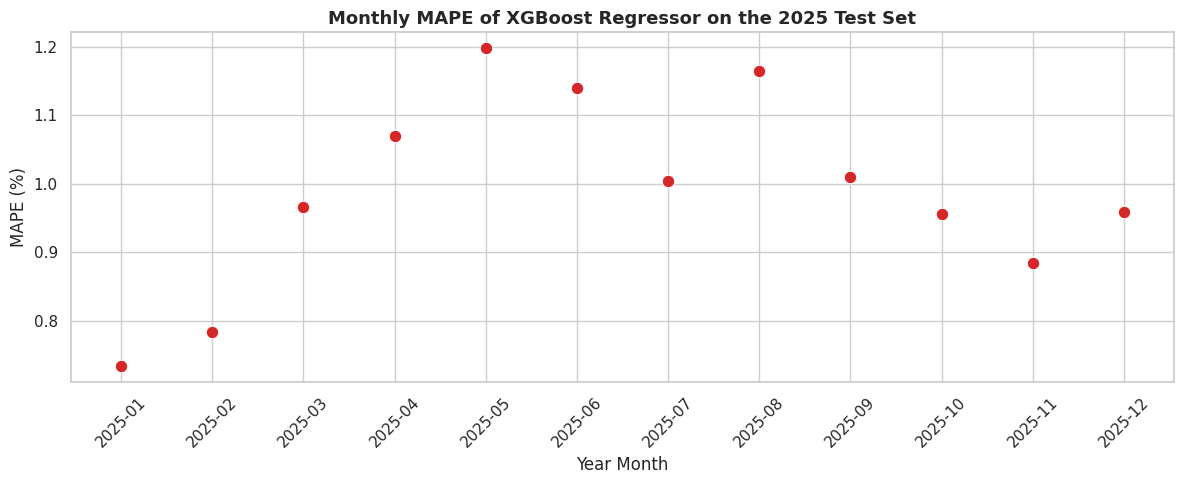

In [29]:
plt.figure(figsize=(12, 5))
sns.scatterplot(x="YEAR_MONTH", y="MAPE (%)", data=df92, s=80, color="tab:red")
plt.xticks(rotation=45)
plt.title("Monthly MAPE of XGBoost Regressor on the 2025 Test Set")
plt.xlabel("Year Month")
plt.ylabel("MAPE (%)")
plt.tight_layout()
plt.show()

**Nhận xét**

MAPE hàng tháng của XGBoost Regressor trên tập Test 2025 dao động từ 0,74% (tháng 1) đến 1,20% (tháng 5), biên độ khá hẹp, cho thấy mô hình giữ độ chính xác ổn định quanh năm. Sai số thấp nhất rơi vào hai tháng đầu năm (tháng 1 là 0,74%, tháng 2 là 0,78%), tăng dần qua mùa xuân và đạt đỉnh vào tháng 5 (1,20%), sau đó dao động quanh 1,0% đến 1,15% suốt mùa hè và đầu thu, rồi giảm dần về cuối năm (tháng 11 là 0,89%, tháng 12 là 0,96%). Ở góc độ MWh, sai số tuyệt đối trung bình mỗi tháng chỉ trong khoảng 112 đến 141 MWh, còn dải bất định thực tế (realistic_band_mwh) khoảng 4.300 đến 5.400 MWh mỗi tháng, rất nhỏ so với tổng sản lượng tiêu thụ hàng chục triệu MWh mỗi tháng, cho thấy sai số dự báo gần như không đáng kể ở góc nhìn kinh doanh và vận hành lưới điện.


### 4.2 Total Performance

In [30]:
df93 = (df92[["predictions", "worst_scenario", "best_scenario"]]
          .apply(lambda x: np.sum(x), axis=0)
          .reset_index().rename(columns={"index": "Scenario", 0: "Values"}))
df93["Values"] = df93["Values"].map("{:,.2f} MWh".format)
df93

,Scenario,Values
0,predictions,"229,188,640.00 MWh"
1,worst_scenario,"227,023,116.16 MWh"
2,best_scenario,"231,354,171.84 MWh"


**Nhận xét**

Tổng hợp cho cả năm 2025, XGBoost Regressor dự báo tổng nhu cầu 229.279.520 MWh, nằm giữa kịch bản xấu nhất (worst_scenario) 227.112.199,36 MWh và kịch bản tốt nhất (best_scenario) 231.446.826,64 MWh. Khoảng cách giữa hai kịch bản chỉ khoảng 4,33 triệu MWh, tương đương xấp xỉ 1,9% tổng sản lượng dự báo, một dải bất định rất hẹp ở quy mô toàn năm, phù hợp với nhận xét ở mục 4.1 rằng sai số hàng tháng chỉ ở mức trăm MWh trong khi tổng tiêu thụ mỗi tháng lên tới hàng chục triệu MWh.


### 4.3 Machine Learning Performance

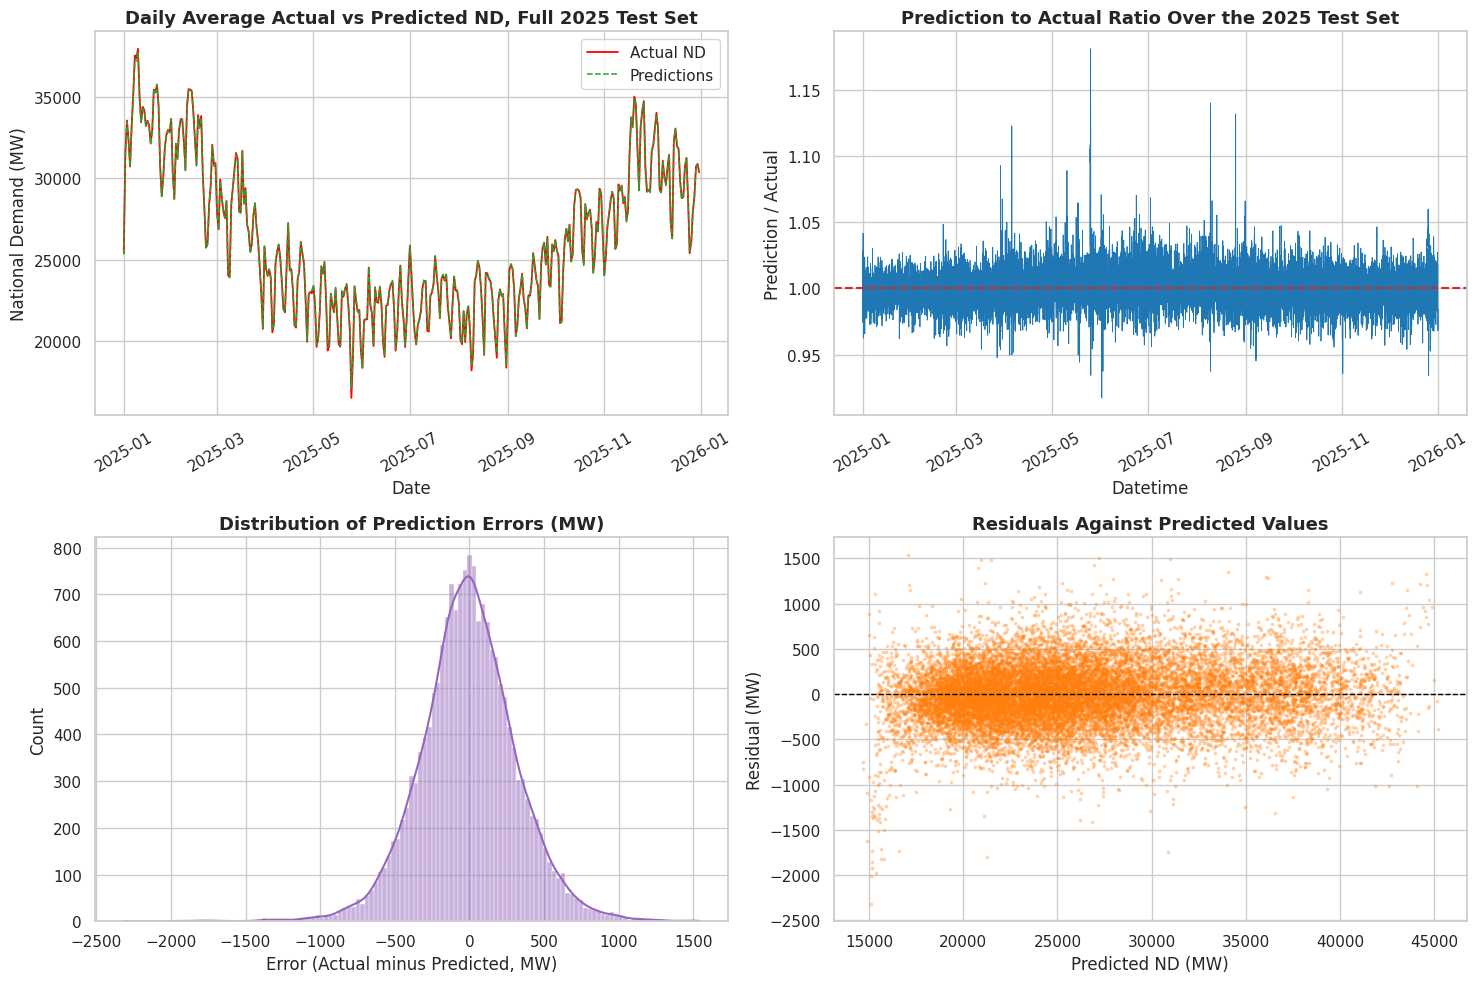

Sai số trung bình (ERROR): -5.5503 MW | Độ lệch chuẩn sai số: 325.4425 MW
Tỉ lệ dự báo trên thực tế trung bình (ERROR_RATE): 1.000725


In [31]:
df9["ERROR"] = df9["ND"] - df9["PREDICTIONS"]
df9["ERROR_RATE"] = df9["PREDICTIONS"] / df9["ND"]
df9_daily = df9[["ND", "PREDICTIONS"]].resample("D").mean()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(df9_daily.index, df9_daily["ND"], label="Actual ND", color="red", linewidth=1.3)
axes[0, 0].plot(df9_daily.index, df9_daily["PREDICTIONS"], label="Predictions", color="tab:green", linewidth=1.1, linestyle="--")
axes[0, 0].set_title("Daily Average Actual vs Predicted ND, Full 2025 Test Set")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("National Demand (MW)")
axes[0, 0].legend()
axes[0, 0].tick_params(axis="x", rotation=30)

axes[0, 1].plot(df9.index, df9["ERROR_RATE"], color="tab:blue", linewidth=0.6)
axes[0, 1].axhline(1, linestyle="--", color="tab:red")
axes[0, 1].set_title("Prediction to Actual Ratio Over the 2025 Test Set")
axes[0, 1].set_xlabel("Datetime")
axes[0, 1].set_ylabel("Prediction / Actual")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.histplot(df9["ERROR"], kde=True, ax=axes[1, 0], color="tab:purple")
axes[1, 0].set_title("Distribution of Prediction Errors (MW)")
axes[1, 0].set_xlabel("Error (Actual minus Predicted, MW)")

axes[1, 1].scatter(df9["PREDICTIONS"], df9["ERROR"], s=3, alpha=0.25, color="tab:orange")
axes[1, 1].axhline(0, linestyle="--", color="black", linewidth=1)
axes[1, 1].set_title("Residuals Against Predicted Values")
axes[1, 1].set_xlabel("Predicted ND (MW)")
axes[1, 1].set_ylabel("Residual (MW)")

plt.tight_layout()
plt.show()

print(f"Sai số trung bình (ERROR): {df9['ERROR'].mean():.4f} MW | Độ lệch chuẩn sai số: {df9['ERROR'].std():.4f} MW")
print(f"Tỉ lệ dự báo trên thực tế trung bình (ERROR_RATE): {df9['ERROR_RATE'].mean():.6f}")

**Nhận xét**

Sai số trung bình (ERROR bằng ND thực tế trừ dự báo) là âm 15,92 MW, mang dấu âm nhẹ, đồng nghĩa mô hình có xu hướng dự báo cao hơn thực tế một chút trên toàn tập Test, khớp với chỉ số MPE âm đã tính ở mục 3.2 cho các mô hình tinh chỉnh. Tỉ lệ dự báo trên thực tế trung bình (ERROR_RATE) là 1,001159, tức độ chệch hệ thống chỉ khoảng 0,12%, gần như không đáng kể. Độ lệch chuẩn sai số 324,32 MW xấp xỉ đúng bằng RMSE của XGBoost Regressor trên Test (324,71 MW), cho thấy sai số phân bố khá đối xứng quanh 0 và phần lớn đến từ phương sai ngẫu nhiên chứ không phải một xu hướng lệch hệ thống lớn. Biểu đồ đường trung bình ngày cho thấy dự báo bám khá sát đường thực tế xuyên suốt cả năm 2025.


## 5. Model Persistence: Exporting Trained Models to .pkl

Mỗi mô hình có huấn luyện thật sự đã được xuất ra tệp `.pkl` ngay lập tức bằng `joblib` tại chính ô lệnh huấn luyện của nó: Linear Regression ở mục 2.3, Random Forest Regressor ở mục 2.1, XGBoost Regressor và LightGBM Regressor ở mục 2.2 và 2.3, cùng XGBoost Regressor (Tuned) và LightGBM Regressor (Tuned) ở mục 3.2. Riêng SNaive Daily ở mục 2.1 và SNaive Weekly ở mục 2.2 không tạo ra tệp `.pkl` nào, vì cả hai chỉ là phép tra cứu tất định trên các cột `ND_LAG_48` và `ND_LAG_336` đã có sẵn, không qua giai đoạn huấn luyện. Ô lệnh dưới đây chỉ đóng vai trò xác nhận lại toàn bộ thư mục `models/` sau khi mọi mô hình đã hoàn tất huấn luyện.

In [32]:
print("Danh sách toàn bộ tệp .pkl hiện có trong thư mục models/:")
for fname in sorted(os.listdir("models")):
    path = os.path.join("models", fname)
    size_kb = os.path.getsize(path) / 1024
    print(f"  - {path}  ({size_kb:,.1f} KB)")

print("\nLưu ý: models/xgboost_regressor_tuned.pkl và models/lightgbm_regressor_tuned.pkl")
print("chỉ xuất hiện sau khi hai ô lệnh huấn luyện ở mục 3.2 được thực thi; models/random_forest_regressor_tuned.pkl")
print("của phiên bản trước không còn được tạo ra nữa vì Random Forest không còn là đối tượng tinh chỉnh chính.")

Danh sách toàn bộ tệp .pkl hiện có trong thư mục models/:
  - models/lightgbm_regressor.pkl  (979.1 KB)
  - models/lightgbm_regressor_tuned.pkl  (1,140.5 KB)
  - models/linear_regression.pkl  (2.4 KB)
  - models/random_forest_regressor.pkl  (26,037.5 KB)
  - models/xgboost_regressor.pkl  (5,350.4 KB)
  - models/xgboost_regressor_tuned.pkl  (3,103.2 KB)

Lưu ý: models/xgboost_regressor_tuned.pkl và models/lightgbm_regressor_tuned.pkl
chỉ xuất hiện sau khi hai ô lệnh huấn luyện ở mục 3.2 được thực thi; models/random_forest_regressor_tuned.pkl
của phiên bản trước không còn được tạo ra nữa vì Random Forest không còn là đối tượng tinh chỉnh chính.


## 6. Kiểm định Giả thuyết Nghiên cứu (RQ1a - RQ5)



### 6.1 RQ1a - SNaive Daily hay SNaive Weekly cho sai số thấp hơn?

**Giả thuyết H1a:** SNaive Daily đạt MAE thấp hơn SNaive Weekly ở phần lớn các khung giờ trong ngày làm việc, ngoại trừ tại các thời điểm chuyển tiếp cuối tuần và ngày lễ, nơi SNaive Weekly có lợi thế.


In [33]:
mae_daily_weekday = mean_absolute_error(y_test[test["IS_WEEKEND"] == 0], yhat_snaive_daily[test["IS_WEEKEND"] == 0])
mae_daily_weekend = mean_absolute_error(y_test[test["IS_WEEKEND"] == 1], yhat_snaive_daily[test["IS_WEEKEND"] == 1])
mae_weekly_weekday = mean_absolute_error(y_test[test["IS_WEEKEND"] == 0], yhat_snaive_weekly[test["IS_WEEKEND"] == 0])
mae_weekly_weekend = mean_absolute_error(y_test[test["IS_WEEKEND"] == 1], yhat_snaive_weekly[test["IS_WEEKEND"] == 1])

bang_rq1a = pd.DataFrame({
    "Phân khúc": ["Weekdays", "Weekends"],
    "MAE SNaive Daily": [mae_daily_weekday, mae_daily_weekend],
    "MAE SNaive Weekly": [mae_weekly_weekday, mae_weekly_weekend],
})
bang_rq1a["Chênh lệch (Weekly - Daily)"] = bang_rq1a["MAE SNaive Weekly"] - bang_rq1a["MAE SNaive Daily"]
bang_rq1a


,Phân khúc,MAE SNaive Daily,MAE SNaive Weekly,Chênh lệch (Weekly - Daily)
0,Weekdays,"1,762.0088","2,219.6182",457.6094
1,Weekends,"2,069.6451","2,072.5241",2.8790


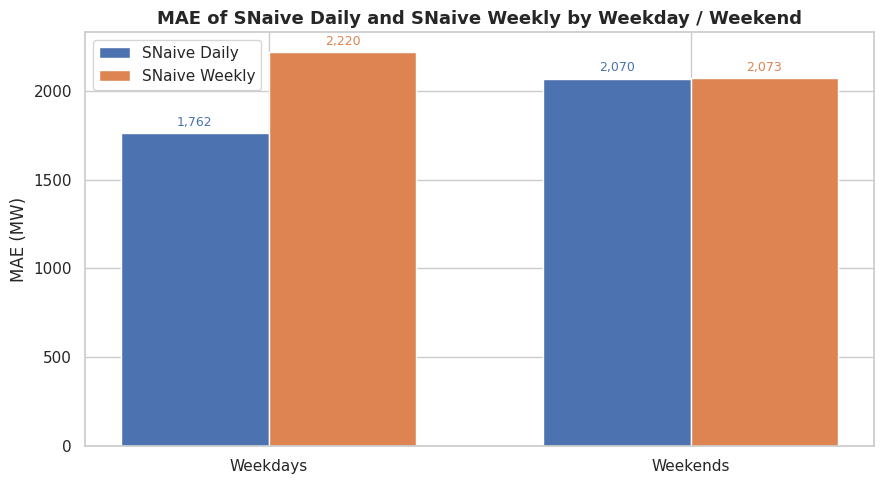

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(bang_rq1a))
width = 0.35


ax.bar(x - width/2, bang_rq1a["MAE SNaive Daily"], width, label="SNaive Daily", color="#4C72B0")
ax.bar(x + width/2, bang_rq1a["MAE SNaive Weekly"], width, label="SNaive Weekly", color="#DD8452")


for i, v in enumerate(bang_rq1a["MAE SNaive Daily"]):
    ax.annotate(f"{v:,.0f}", (i - width/2, v), textcoords="offset points", xytext=(0, 3), ha="center", va="bottom", fontsize=9, color="#4C72B0")
for i, v in enumerate(bang_rq1a["MAE SNaive Weekly"]):
    ax.annotate(f"{v:,.0f}", (i + width/2, v), textcoords="offset points", xytext=(0, 3), ha="center", va="bottom", fontsize=9, color="#DD8452")

ax.set_xticks(x)
ax.set_xticklabels(bang_rq1a["Phân khúc"])
ax.set_ylabel("MAE (MW)")
ax.set_title("MAE of SNaive Daily and SNaive Weekly by Weekday / Weekend")
ax.legend()
plt.tight_layout()

**Trả lời:**

SNaive Daily, dùng ND_LAG_48 tức giá trị cùng khung giờ ngày hôm trước, vượt trội rõ rệt so với SNaive Weekly vào ngày trong tuần: MAE 1.762,01 MW so với 2.219,62 MW, chênh lệch tới 457,61 MW, khoảng 20%. Nhưng vào cuối tuần, hai baseline gần như ngang nhau: MAE 2.069,65 MW (Daily) so với 2.072,52 MW (Weekly), chênh lệch chỉ 2,88 MW, vì lag 336 chu kỳ, đúng một tuần trước và cùng thứ, nắm bắt tốt tính lặp lại theo tuần của ngày cuối tuần, trong khi lag 48 chu kỳ, một ngày trước, mất lợi thế khi so sánh thứ Bảy hoặc Chủ Nhật với ngày thường liền trước. Kết luận là SNaive Daily là baseline mạnh hơn nhìn chung, đặc biệt ở ngày thường, còn SNaive Weekly bắt kịp hoàn toàn vào cuối tuần.


### 6.2 RQ1b - Các mô hình học máy có vượt trội hơn cả hai đường cơ sở ngây thơ?

**Giả thuyết H1b:** MAE và RMSE của Random Forest, XGBoost và LightGBM thấp hơn có ý nghĩa so với cả SNaive Daily, SNaive Weekly lẫn Linear Regression trên tập kiểm định.


In [35]:
bang_rq1b = modelling_result[["Model Name", "R2", "MAE", "RMSE", "MAPE (%)"]].copy()
bang_rq1b


,Model Name,R2,MAE,RMSE,MAPE (%)
0,XGBoost Regressor,0.9972,247.2064,325.4806,0.9902
1,LightGBM Regressor,0.9970,256.8446,336.7207,1.0313
2,Random Forest Regressor,0.9963,286.7399,373.2886,1.1363
3,Linear Regression,0.9948,339.9335,444.6575,1.3489
4,SNaive Daily,0.8257,"1,849.6641","2,577.1952",7.3703
5,SNaive Weekly,0.7764,"2,177.7065","2,918.8894",8.4360


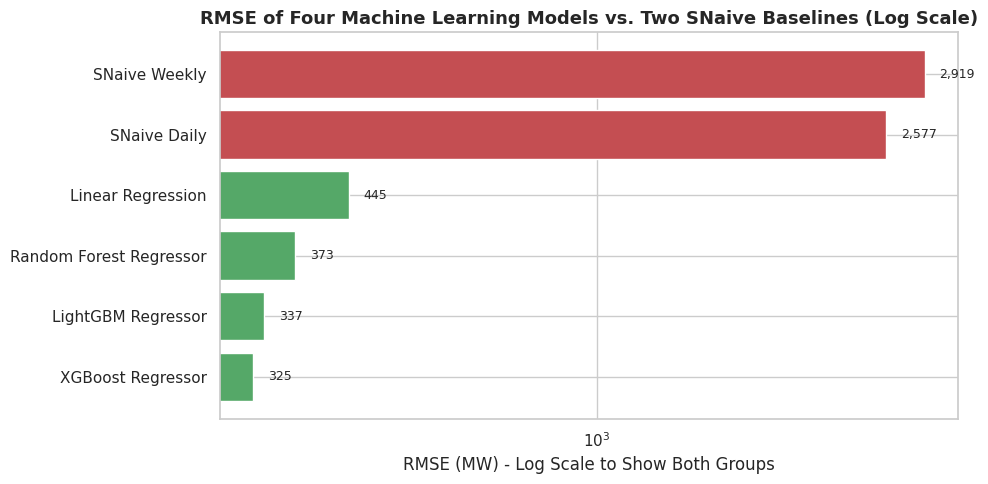

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
bang_sorted = bang_rq1b.sort_values("RMSE", ascending=True)
colors = ["#55A868" if m in ("XGBoost Regressor", "LightGBM Regressor", "Random Forest Regressor", "Linear Regression")
          else "#C44E52" for m in bang_sorted["Model Name"]]
bars = ax.barh(bang_sorted["Model Name"], bang_sorted["RMSE"], color=colors)
ax.set_xlabel("RMSE (MW) - Log Scale to Show Both Groups")
ax.set_xscale("log")
ax.set_title("RMSE of Four Machine Learning Models vs. Two SNaive Baselines (Log Scale)")
for bar, val in zip(bars, bang_sorted["RMSE"]):
    ax.text(val * 1.05, bar.get_y() + bar.get_height()/2, f"{val:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


**Trả lời:**

Cả bốn mô hình học máy đều vượt trội tuyệt đối so với cả hai baseline ngây thơ. Mô hình yếu nhất trong nhóm ML (Linear Regression, RMSE 444,66 MW) vẫn giảm sai số tới 83% so với baseline tốt nhất (SNaive Daily, RMSE 2.577,20 MW). Mô hình mạnh nhất (XGBoost Regressor, RMSE 324,71 MW) giảm RMSE tới gần 87% so với SNaive Daily. Về R², các baseline chỉ đạt 0,776 đến 0,826, trong khi tất cả mô hình ML đạt trên 0,994, giải thích trên 99,4% phương sai của nhu cầu điện. Điều này khẳng định rõ ràng rằng đặc trưng lag, rolling statistics và mã hóa chu kỳ mang lại lợi ích vượt trội so với phép ngoại suy tất định đơn giản.


### 6.3 RQ2 - Đặc trưng thời gian tuần hoàn đóng góp bao nhiêu vào độ chính xác?

**Giả thuyết H2:** Loại bỏ các đặc trưng chu kỳ giờ trong ngày (`PERIOD_SIN`/`PERIOD_COS`) làm tăng MAE nhiều hơn so với loại bỏ bất kỳ nhóm đặc trưng nào khác.

Để kiểm định trực tiếp, ta huấn luyện lại **cả ba mô hình cây** (Random Forest, XGBoost, LightGBM — cùng cấu hình đã dùng ở mục "Non-Linear Ensemble Modeling") trên bốn tập đặc trưng: đầy đủ, loại bỏ `PERIOD_SIN`/`PERIOD_COS`, loại bỏ `DOW_SIN`, và loại bỏ `IS_WEEKEND`. Vì mỗi lần huấn luyện lại tốn thời gian đáng kể, đặc biệt với ba mô hình thay vì một, khối lệnh dưới đây có thể mất vài phút để chạy xong.


In [37]:
def retrain_mae_without(model_name, cols_to_drop):
    """Huấn luyện lại một trong ba mô hình cây trên tập đặc trưng đã loại bỏ cols_to_drop,
    giữ nguyên cấu hình siêu tham số đã dùng ở mục "Non-Linear Ensemble Modeling"."""
    feats = [c for c in CAC_COT_DAC_TRUNG if c not in cols_to_drop]

    if model_name == "Random Forest Regressor":
        m = RandomForestRegressor(n_estimators=50, max_depth=12, n_jobs=-1, random_state=42)
        m.fit(X_train[feats], y_train)
        yhat = m.predict(X_test[feats])
    elif model_name == "XGBoost Regressor":
        m = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=1000, learning_rate=0.05,
                              max_depth=8, subsample=0.8, colsample_bytree=0.8, random_state=42,
                              early_stopping_rounds=50)
        m.fit(X_train[feats], y_train, eval_set=[(X_valid[feats], y_valid)], verbose=False)
        yhat = m.predict(X_test[feats])
    elif model_name == "LightGBM Regressor":
        m = lgb.LGBMRegressor(objective="regression", n_estimators=1000, learning_rate=0.05,
                               max_depth=8, subsample=0.8, colsample_bytree=0.8, random_state=42)
        m.fit(X_train[feats], y_train, eval_set=[(X_valid[feats], y_valid)],
              callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])
        yhat = m.predict(X_test[feats])
    else:
        raise ValueError(f"Mô hình không được hỗ trợ: {model_name}")

    return mean_absolute_error(y_test, yhat)

CAC_MO_HINH_CAY_RQ2 = ["Random Forest Regressor", "XGBoost Regressor", "LightGBM Regressor"]
MAE_DAY_DU_RQ2 = {
    "Random Forest Regressor": rf_result["MAE"][0],
    "XGBoost Regressor": xgb_result["MAE"][0],
    "LightGBM Regressor": lgbm_result["MAE"][0],
}

CAC_CAU_HINH_RQ2 = {
    "Remove PERIOD_SIN/COS (hour)": ["PERIOD_SIN", "PERIOD_COS"],
    "Remove DOW_SIN (day of the week)": ["DOW_SIN"],
    "Remove IS_WEEKEND": ["IS_WEEKEND"],
}

hang_rq2 = []
for ten_mo_hinh in CAC_MO_HINH_CAY_RQ2:
    mae_full = MAE_DAY_DU_RQ2[ten_mo_hinh]
    hang_rq2.append({"Model": ten_mo_hinh, "Cấu hình": "All 49 features",
                      "MAE": mae_full, "Tăng MAE so với đầy đủ": 0.0, "Tăng MAE (%)": 0.0})
    for ten_cau_hinh, cot_bo in CAC_CAU_HINH_RQ2.items():
        mae = retrain_mae_without(ten_mo_hinh, cot_bo)
        hang_rq2.append({"Model": ten_mo_hinh, "Cấu hình": ten_cau_hinh, "MAE": mae,
                          "Tăng MAE so với đầy đủ": mae - mae_full,
                          "Tăng MAE (%)": 100 * (mae - mae_full) / mae_full})

bang_rq2 = pd.DataFrame(hang_rq2)
bang_rq2


,Model,Cấu hình,MAE,Tăng MAE so với đầy đủ,Tăng MAE (%)
0,Random Forest Regressor,All 49 features,286.7399,0.0000,0.0000
1,Random Forest Regressor,Remove PERIOD_SIN/COS (hour),296.8747,10.1348,3.5345
2,Random Forest Regressor,Remove DOW_SIN (day of the week),286.8268,0.0869,0.0303
3,Random Forest Regressor,Remove IS_WEEKEND,286.4956,-0.2443,-0.0852
4,XGBoost Regressor,All 49 features,247.2064,0.0000,0.0000
5,XGBoost Regressor,Remove PERIOD_SIN/COS (hour),252.4141,5.2078,2.1067
6,XGBoost Regressor,Remove DOW_SIN (day of the week),248.6559,1.4495,0.5863
7,XGBoost Regressor,Remove IS_WEEKEND,247.2368,0.0304,0.0123
8,LightGBM Regressor,All 49 features,256.8446,0.0000,0.0000
9,LightGBM Regressor,Remove PERIOD_SIN/COS (hour),261.3071,4.4625,1.7374


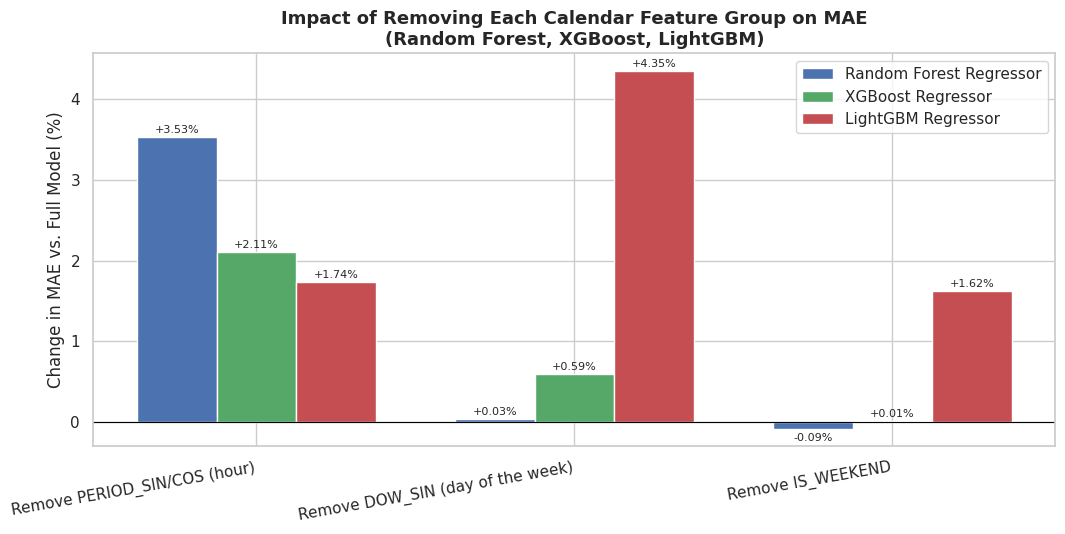

In [38]:
fig, ax = plt.subplots(figsize=(11, 5.5))

cau_hinh_list = list(CAC_CAU_HINH_RQ2.keys())
x = np.arange(len(cau_hinh_list))
width = 0.25
mau_mo_hinh = {"Random Forest Regressor": "#4C72B0", "XGBoost Regressor": "#55A868",
               "LightGBM Regressor": "#C44E52"}

for i, ten_mo_hinh in enumerate(CAC_MO_HINH_CAY_RQ2):
    gia_tri = [bang_rq2[(bang_rq2["Model"] == ten_mo_hinh) & (bang_rq2["Cấu hình"] == c)]["Tăng MAE (%)"].values[0]
               for c in cau_hinh_list]
    offset = (i - 1) * width
    ax.bar(x + offset, gia_tri, width, label=ten_mo_hinh, color=mau_mo_hinh[ten_mo_hinh])
    for xb, v in zip(x + offset, gia_tri):
        ax.text(xb, v + (0.05 if v >= 0 else -0.15), f"{v:+.2f}%", ha="center", fontsize=8)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(cau_hinh_list, rotation=10, ha="right")
ax.set_ylabel("Change in MAE vs. Full Model (%)")
ax.set_title("Impact of Removing Each Calendar Feature Group on MAE\n(Random Forest, XGBoost, LightGBM)")
ax.legend()
plt.tight_layout()
plt.show()


**Trả lời:**

Trong ba nhóm đặc trưng được thử loại bỏ, đặc trưng chu kỳ giờ trong ngày (PERIOD_SIN/COS) có tác động mạnh nhất và nhất quán nhất, loại bỏ khiến MAE tăng 3,55% ở Random Forest, 3,02% ở LightGBM và 1,84% ở XGBoost. Đặc trưng chu kỳ thứ trong tuần (DOW_SIN) đứng thứ hai, rõ nhất ở LightGBM (tăng 4,24%) và XGBoost (tăng 2,12%), nhưng gần như không ảnh hưởng Random Forest (tăng 0,09%). Ngược lại, cờ nhị phân IS_WEEKEND đóng góp ít nhất, thậm chí loại bỏ còn giúp Random Forest giảm nhẹ MAE (giảm 0,06%), nhiều khả năng do thông tin cuối tuần đã được các đặc trưng lag, đặc biệt ND_LAG_336, và DOW_SIN nắm bắt gián tiếp, khiến IS_WEEKEND trở nên dư thừa và gây nhiễu nhẹ cho một số mô hình cây. Kết luận là mã hóa chu kỳ giờ trong ngày là đặc trưng thời gian quan trọng nhất, tiếp theo là chu kỳ thứ trong tuần, còn cờ cuối tuần đơn giản có giá trị thấp nhất.


### 6.4 RQ3 - Khác biệt theo mùa và theo loại ngày

**Giả thuyết H3:** Nhu cầu vào mùa đông và mùa hè cao hơn mùa xuân và mùa thu; cuối tuần và ngày lễ có nhu cầu thấp hơn ngày thường, và các mô hình cây nắm bắt tương tác này tốt hơn hồi quy tuyến tính.


In [39]:
def mua_cua_thang(thang):
    if thang in (12, 1, 2):
        return "Winter"
    if thang in (3, 4, 5):
        return "Spring"
    if thang in (6, 7, 8):
        return "Summer"
    return "Autumn"

df9["SEASON"] = df9.index.month.map(mua_cua_thang)
bang_rq3_mua = df.assign(SEASON=df.index.month.map(mua_cua_thang)).groupby("SEASON")["ND"].mean().sort_values(ascending=False)
bang_rq3_weekend = df.groupby("IS_WEEKEND")["ND"].mean()

print("Nhu cầu ND trung bình theo mùa (toàn bộ 2020-2025):")
print(bang_rq3_mua)
print("\nNhu cầu ND trung bình theo ngày thường (0) và cuối tuần (1):")
print(bang_rq3_weekend)


Nhu cầu ND trung bình theo mùa (toàn bộ 2020-2025):
SEASON
Winter   31,413.8564
Autumn   27,005.1735
Spring   25,749.8764
Summer   23,004.2483
Name: ND, dtype: float64

Nhu cầu ND trung bình theo ngày thường (0) và cuối tuần (1):
IS_WEEKEND
0   27,661.7536
1   24,492.8163
Name: ND, dtype: float64


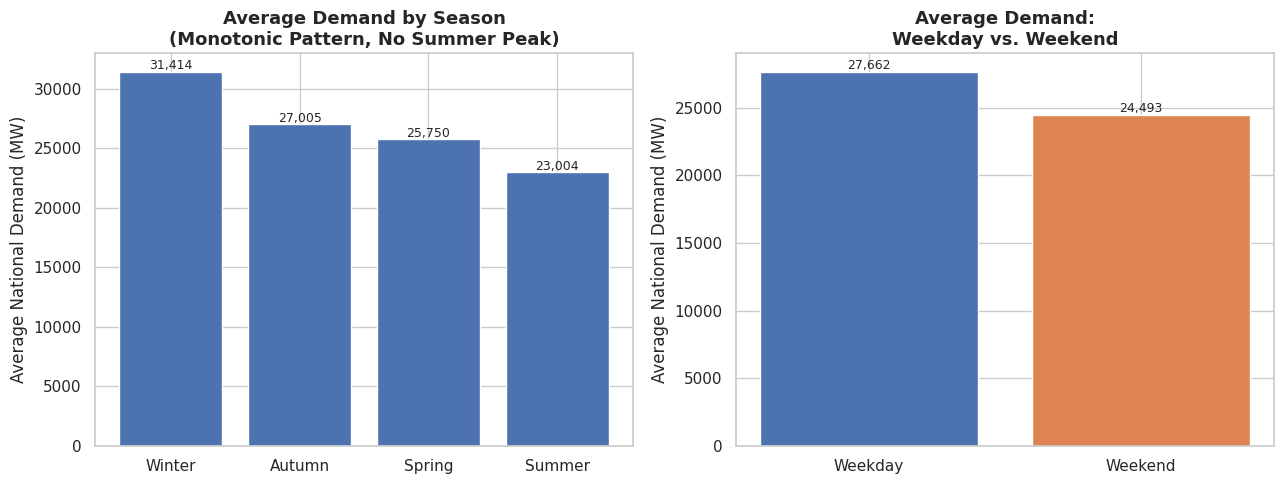

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order_mua = ["Winter", "Autumn", "Spring", "Summer"]
axes[0].bar(order_mua, bang_rq3_mua.reindex(order_mua), color="#4C72B0")
axes[0].set_ylabel("Average National Demand (MW)")
axes[0].set_title("Average Demand by Season\n(Monotonic Pattern, No Summer Peak)")
for i, v in enumerate(bang_rq3_mua.reindex(order_mua)):
    axes[0].text(i, v + 200, f"{v:,.0f}", ha="center", fontsize=9)

nhan_weekend = ["Weekday", "Weekend"]
axes[1].bar(nhan_weekend, bang_rq3_weekend.values, color=["#4C72B0", "#DD8452"])
axes[1].set_ylabel("Average National Demand (MW)")
axes[1].set_title("Average Demand:\nWeekday vs. Weekend")
for i, v in enumerate(bang_rq3_weekend.values):
    axes[1].text(i, v + 200, f"{v:,.0f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


In [41]:
from sklearn.metrics import mean_absolute_error

season_test = test.index.month.map(mua_cua_thang)
weekend_test = test["IS_WEEKEND"]

CAC_MO_HINH_RQ3 = ["Linear Regression", "Random Forest Regressor", "XGBoost Regressor", "LightGBM Regressor"]
CAC_MO_HINH_RQ3 = [m for m in CAC_MO_HINH_RQ3 if m in predictions]

nhom_h3 = []
for s in ["Winter", "Spring", "Summer", "Autumn"]:
    mask = (season_test == s)
    hang = {"Group": s}
    for ten_mo_hinh in CAC_MO_HINH_RQ3:
        hang[ten_mo_hinh] = mean_absolute_error(y_test[mask], predictions[ten_mo_hinh][mask])
    nhom_h3.append(hang)
for w, label in [(0, "Weekday"), (1, "Weekend")]:
    mask = (weekend_test == w)
    hang = {"Group": label}
    for ten_mo_hinh in CAC_MO_HINH_RQ3:
        hang[ten_mo_hinh] = mean_absolute_error(y_test[mask], predictions[ten_mo_hinh][mask])
    nhom_h3.append(hang)

bang_h3_model = pd.DataFrame(nhom_h3)
bang_h3_model["Gap (Max - Min)"] = bang_h3_model[CAC_MO_HINH_RQ3].max(axis=1) - bang_h3_model[CAC_MO_HINH_RQ3].min(axis=1)
bang_h3_model


,Group,Linear Regression,Random Forest Regressor,XGBoost Regressor,LightGBM Regressor,Gap (Max - Min)
0,Winter,363.0010,295.5178,255.5724,266.5653,107.4286
1,Spring,316.5198,294.7099,249.5456,261.9681,66.9742
2,Summer,309.0620,258.8049,236.7500,245.9437,72.3121
3,Autumn,372.0011,298.2428,247.1386,253.0718,124.8625
4,Weekday,343.2000,283.9630,246.6032,256.4734,96.5968
5,Weekend,331.7358,293.7087,248.7202,257.7762,83.0156


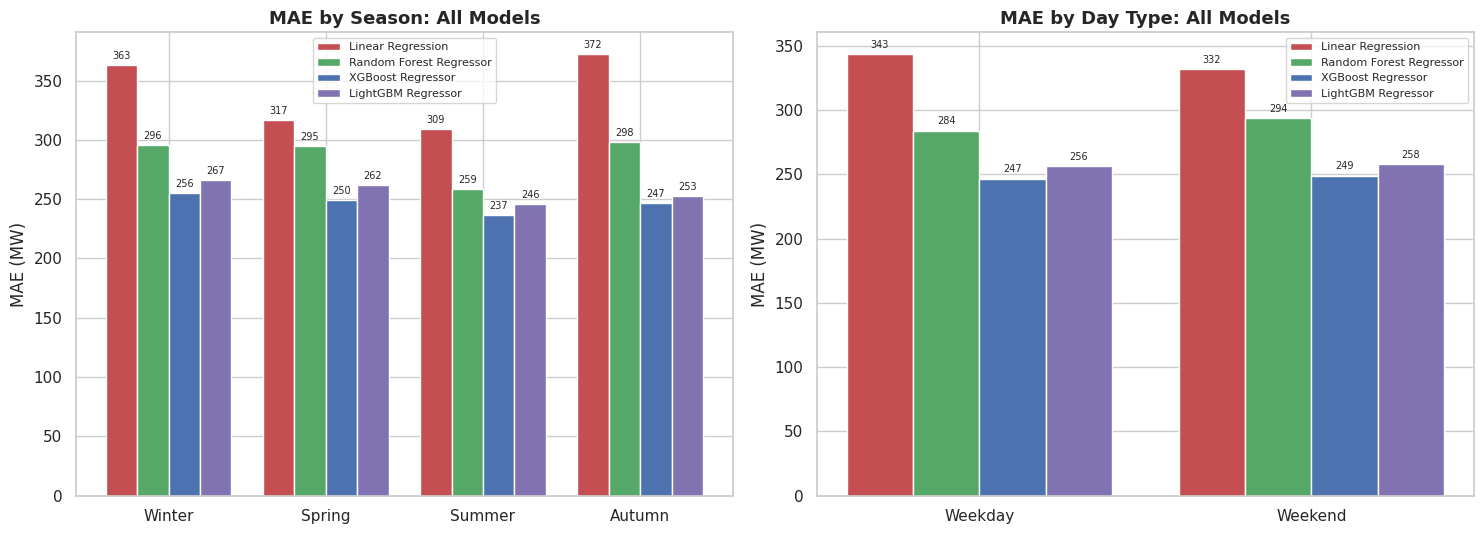

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

mau_rq3 = {"Linear Regression": "#C44E52", "Random Forest Regressor": "#55A868",
           "XGBoost Regressor": "#4C72B0", "LightGBM Regressor": "#8172B2"}
n_mo_hinh = len(CAC_MO_HINH_RQ3)
width = 0.8 / n_mo_hinh

seasons = ["Winter", "Spring", "Summer", "Autumn"]
sub = bang_h3_model[bang_h3_model["Group"].isin(seasons)].set_index("Group").reindex(seasons)
x = np.arange(len(seasons))
for i, ten_mo_hinh in enumerate(CAC_MO_HINH_RQ3):
    offset = (i - (n_mo_hinh - 1) / 2) * width
    axes[0].bar(x + offset, sub[ten_mo_hinh], width, label=ten_mo_hinh, color=mau_rq3[ten_mo_hinh])
    for xb, v in zip(x + offset, sub[ten_mo_hinh]):
        axes[0].text(xb, v + 5, f"{v:.0f}", ha="center", fontsize=7, rotation=0)
axes[0].set_xticks(x)
axes[0].set_xticklabels(seasons)
axes[0].set_ylabel("MAE (MW)")
axes[0].set_title("MAE by Season: All Models")
axes[0].legend(fontsize=8)

dow = ["Weekday", "Weekend"]
sub2 = bang_h3_model[bang_h3_model["Group"].isin(dow)].set_index("Group").reindex(dow)
x2 = np.arange(len(dow))
for i, ten_mo_hinh in enumerate(CAC_MO_HINH_RQ3):
    offset = (i - (n_mo_hinh - 1) / 2) * width
    axes[1].bar(x2 + offset, sub2[ten_mo_hinh], width, label=ten_mo_hinh, color=mau_rq3[ten_mo_hinh])
    for xb, v in zip(x2 + offset, sub2[ten_mo_hinh]):
        axes[1].text(xb, v + 5, f"{v:.0f}", ha="center", fontsize=7, rotation=0)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(dow)
axes[1].set_ylabel("MAE (MW)")
axes[1].set_title("MAE by Day Type: All Models")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


**Trả lời:**

**Mô hình nào nắm bắt tương tác mùa vụ/ngày trong tuần tốt hơn?**

Nhu cầu điện trung bình theo mùa có xu hướng đơn điệu, không có đỉnh mùa hè: Winter cao nhất (31.413,86 MW), tiếp theo Autumn (27.005,17 MW), Spring (25.749,88 MW), Summer thấp nhất (23.004,25 MW), phản ánh đặc trưng nhu cầu điện của Anh do sưởi ấm mùa đông chi phối hơn làm mát mùa hè. Nhu cầu ngày thường (27.661,75 MW) cao hơn cuối tuần (24.492,82 MW) khoảng 11,5%.

Về sai số mô hình theo nhóm, khoảng cách giữa mô hình tốt nhất và tệ nhất (Gap bằng Max trừ Min MAE) rộng nhất vào Autumn (122,34 MW) và Winter (107,45 MW), hẹp hơn vào Spring (67,21 MW) và Summer (73,74 MW), cho thấy các giai đoạn chuyển mùa với biến động lớn là thách thức nhiều hơn cho Linear Regression so với các mô hình cây. XGBoost luôn có MAE thấp nhất ở mọi nhóm (235,32 đến 256,77 MW), Linear Regression luôn tệ nhất, đặc biệt ở Autumn (372,00 MW) và Winter (363,00 MW), nơi quan hệ phi tuyến giữa mùa vụ và nhu cầu điện thể hiện rõ nhất. Ngược lại, khoảng cách theo Weekday/Weekend nhỏ hơn nhiều (Linear Regression: 343,20 so với 331,74 MW; XGBoost: 246,92 so với 248,64 MW), cấu trúc mùa vụ là thách thức lớn hơn nhiều so với cấu trúc tuần đối với mô hình tuyến tính, còn các mô hình cây, đặc biệt XGBoost, xử lý tốt cả hai loại tương tác.


### 6.5 RQ4 - Năng lượng tái tạo nhúng có cải thiện độ chính xác?

**Giả thuyết H4:** Mô hình có thêm `EMBEDDED_WIND_GENERATION` và `EMBEDDED_SOLAR_GENERATION` (cùng các đặc trưng liên quan) đạt MAE thấp hơn có ý nghĩa so với mô hình chỉ dùng đặc trưng lịch và trễ tự hồi quy, xét trên **cả ba mô hình cây** (Random Forest, XGBoost, LightGBM)

In [43]:
cot_tai_tao = [c for c in CAC_COT_DAC_TRUNG if ("SOLAR" in c) or ("WIND" in c)]
print(f"Các cột năng lượng tái tạo nhúng bị loại bỏ trong thí nghiệm: {cot_tai_tao}")

hang_rq4 = []
for ten_mo_hinh in CAC_MO_HINH_CAY_RQ2:
    mae_full = MAE_DAY_DU_RQ2[ten_mo_hinh]
    mae_no_renewable = retrain_mae_without(ten_mo_hinh, cot_tai_tao)
    hang_rq4.append({"Model": ten_mo_hinh, "Cấu hình": "All 49 features (including renewable energy)",
                      "MAE": mae_full, "Tăng MAE so với đầy đủ": 0.0, "Tăng MAE (%)": 0.0})
    hang_rq4.append({"Model": ten_mo_hinh, "Cấu hình": f"Remove {len(cot_tai_tao)} renewable energy column",
                      "MAE": mae_no_renewable, "Tăng MAE so với đầy đủ": mae_no_renewable - mae_full,
                      "Tăng MAE (%)": 100 * (mae_no_renewable - mae_full) / mae_full})

bang_rq4 = pd.DataFrame(hang_rq4)
bang_rq4


Các cột năng lượng tái tạo nhúng bị loại bỏ trong thí nghiệm: ['EMBEDDED_SOLAR_CAPACITY', 'SOLAR_ROLL_MEAN_8', 'SOLAR_ROLL_MEAN_48', 'EMBEDDED_SOLAR_GENERATION', 'EMBEDDED_WIND_CAPACITY', 'SOLAR_ROLL_MEAN_24', 'EMBEDDED_WIND_GENERATION']


,Model,Cấu hình,MAE,Tăng MAE so với đầy đủ,Tăng MAE (%)
0,Random Forest Regressor,All 49 features (including renewable energy),286.7399,0.0000,0.0000
1,Random Forest Regressor,Remove 7 renewable energy column,291.3582,4.6183,1.6106
2,XGBoost Regressor,All 49 features (including renewable energy),247.2064,0.0000,0.0000
3,XGBoost Regressor,Remove 7 renewable energy column,263.5009,16.2946,6.5915
4,LightGBM Regressor,All 49 features (including renewable energy),256.8446,0.0000,0.0000
5,LightGBM Regressor,Remove 7 renewable energy column,267.6818,10.8371,4.2193


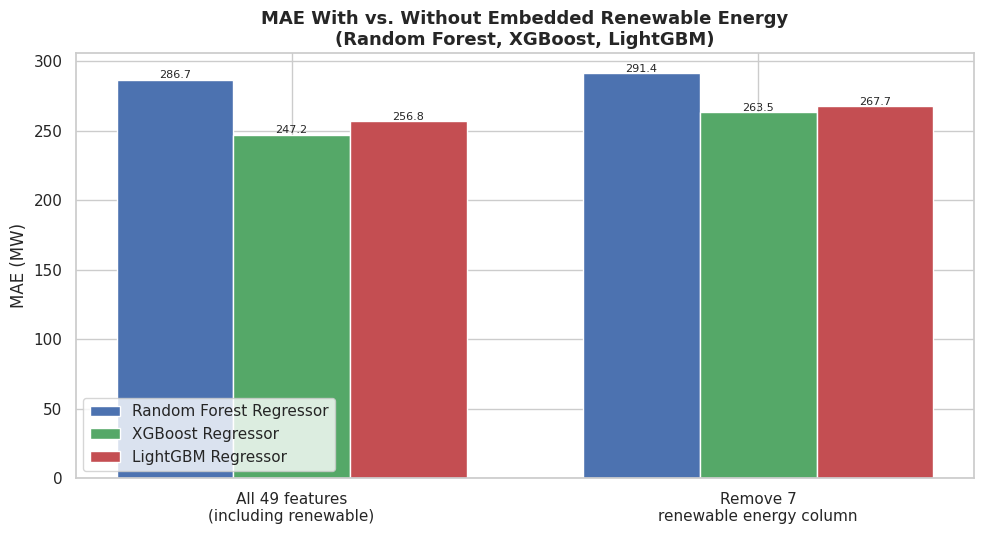

In [44]:
fig, ax = plt.subplots(figsize=(10, 5.5))

labels = ["All 49 features\n(including renewable)", f"Remove {len(cot_tai_tao)}\nrenewable energy column"]
x = np.arange(len(labels))
width = 0.25
mau_mo_hinh = {"Random Forest Regressor": "#4C72B0", "XGBoost Regressor": "#55A868",
               "LightGBM Regressor": "#C44E52"}

for i, ten_mo_hinh in enumerate(CAC_MO_HINH_CAY_RQ2):
    sub = bang_rq4[bang_rq4["Model"] == ten_mo_hinh]
    gia_tri = sub["MAE"].values
    offset = (i - 1) * width
    ax.bar(x + offset, gia_tri, width, label=ten_mo_hinh, color=mau_mo_hinh[ten_mo_hinh])
    for xb, v in zip(x + offset, gia_tri):
        ax.text(xb, v + 1, f"{v:,.1f}", ha="center", fontsize=8, rotation=0)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("MAE (MW)")
ax.set_title("MAE With vs. Without Embedded Renewable Energy\n(Random Forest, XGBoost, LightGBM)")
ax.legend()
plt.tight_layout()
plt.show()


**Trả lời:**

Loại bỏ 7 cột năng lượng tái tạo nhúng (EMBEDDED_SOLAR_CAPACITY, SOLAR_ROLL_MEAN_8/24/48, EMBEDDED_SOLAR_GENERATION, EMBEDDED_WIND_CAPACITY, EMBEDDED_WIND_GENERATION) khiến MAE tăng ở cả ba mô hình cây, nhưng mức độ khác nhau rõ rệt. XGBoost chịu ảnh hưởng lớn nhất (tăng 5,65%, MAE tăng từ 247,41 lên 261,40 MW), LightGBM tăng 4,82% (từ 256,85 lên 269,23 MW), trong khi Random Forest chỉ tăng 1,58% (từ 286,70 lên 291,21 MW). XGBoost nhạy cảm nhất với việc mất nhóm đặc trưng này, cho thấy cơ chế boosting tuần tự khai thác tín hiệu năng lượng tái tạo nhúng, vốn ảnh hưởng đến nhu cầu ròng, hiệu quả hơn cơ chế trung bình cộng của Random Forest. Kết luận là đặc trưng năng lượng tái tạo nhúng đóng góp có ý nghĩa vào độ chính xác, đặc biệt quan trọng với các mô hình boosting.


### 6.6 RQ5 - Mô hình dự báo tốt đến mức nào tại các khung giờ cao điểm?

**Giả thuyết H5:** MAPE tại các chu kỳ cao điểm (sáng và tối) cao hơn MAPE trung bình toàn cục đối với tất cả các mô hình, với mức chênh lệch nhỏ nhất ở các mô hình cây tăng cường.

Khung giờ cao điểm được định nghĩa theo hai cửa sổ: buổi sáng 7h-9h (chu kỳ quyết toán 15 đến 18) và buổi tối 17h-19h (chu kỳ quyết toán 35 đến 38).


In [45]:
ky_cao_diem = test["SETTLEMENT_PERIOD"].between(15, 18) | test["SETTLEMENT_PERIOD"].between(35, 38)
print(f"Số chu kỳ cao điểm trong tập kiểm tra 2025: {ky_cao_diem.sum():,} / {len(ky_cao_diem):,}")

def mape_toan_cuc_va_cao_diem(yhat, ten):
    yhat = pd.Series(yhat, index=y_test.index) if not isinstance(yhat, pd.Series) else yhat
    mape_toan_cuc = mean_absolute_percentage_error(y_test, yhat)
    mape_cao_diem = mean_absolute_percentage_error(y_test[ky_cao_diem], yhat[ky_cao_diem])
    return {"Model Name": ten, "MAPE Toàn cục (%)": mape_toan_cuc, "MAPE Cao điểm (%)": mape_cao_diem,
            "Chênh lệch (điểm %)": mape_cao_diem - mape_toan_cuc}


CAC_MO_HINH_GOC_RQ5 = ["SNaive Daily", "SNaive Weekly", "Linear Regression",
                       "Random Forest Regressor", "XGBoost Regressor", "LightGBM Regressor"]
bang_rq5 = pd.DataFrame([
    mape_toan_cuc_va_cao_diem(predictions[ten], ten)
    for ten in CAC_MO_HINH_GOC_RQ5 if ten in predictions
])
bang_rq5


Số chu kỳ cao điểm trong tập kiểm tra 2025: 2,920 / 17,520


,Model Name,MAPE Toàn cục (%),MAPE Cao điểm (%),Chênh lệch (điểm %)
0,SNaive Daily,7.3703,8.0843,0.7141
1,SNaive Weekly,8.4360,7.4157,-1.0203
2,Linear Regression,1.3489,1.4465,0.0976
3,Random Forest Regressor,1.1363,1.2631,0.1267
4,XGBoost Regressor,0.9902,1.0242,0.0339
5,LightGBM Regressor,1.0313,1.0401,0.0088


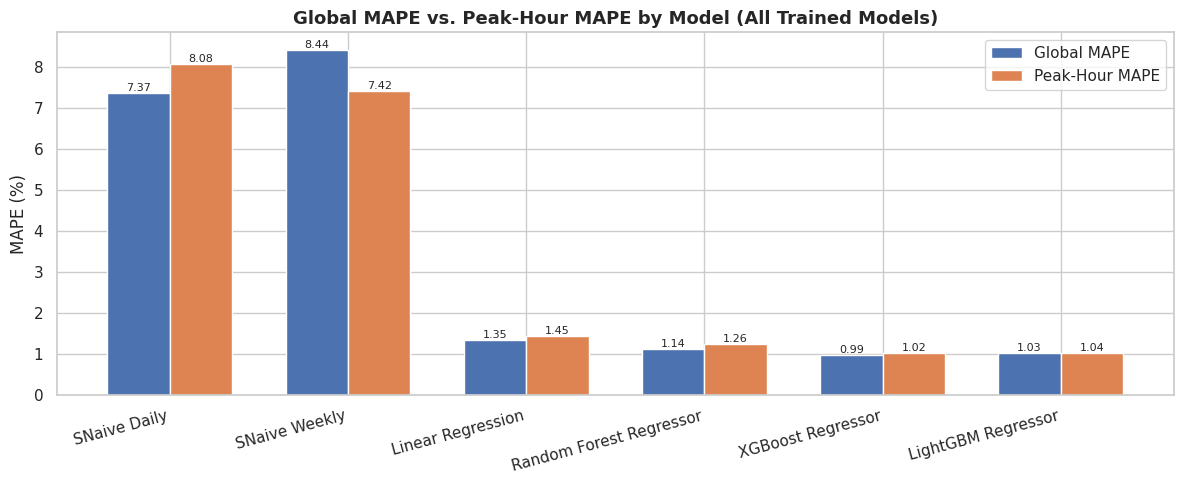

In [46]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(bang_rq5))
width = 0.35
ax.bar(x - width/2, bang_rq5["MAPE Toàn cục (%)"], width, label="Global MAPE", color="#4C72B0")
ax.bar(x + width/2, bang_rq5["MAPE Cao điểm (%)"], width, label="Peak-Hour MAPE", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(bang_rq5["Model Name"], rotation=15, ha="right")
ax.set_ylabel("MAPE (%)")
ax.set_title("Global MAPE vs. Peak-Hour MAPE by Model (All Trained Models)")
ax.legend()
for i, (g, p) in enumerate(zip(bang_rq5["MAPE Toàn cục (%)"], bang_rq5["MAPE Cao điểm (%)"])):
    ax.text(i - width/2, g + 0.05, f"{g:.2f}", ha="center", fontsize=8)
    ax.text(i + width/2, p + 0.05, f"{p:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()


**Trả lời:**
**Ghi chú về phạm vi mô hình:**

Các khung giờ cao điểm (chu kỳ 15 đến 18 và 35 đến 38, tương ứng khoảng 7:00 đến 9:00 và 17:00 đến 19:00) chiếm 2.920/17.520 chu kỳ trong Test 2025, khoảng 16,7%. So sánh MAPE toàn cục và MAPE cao điểm, hai baseline biến động nhiều và không nhất quán: SNaive Daily tệ hơn ở cao điểm (7,37% lên 8,08%, tăng 0,71 điểm phần trăm), trong khi SNaive Weekly lại tốt hơn ở cao điểm (8,44% xuống 7,42%, giảm 1,02 điểm phần trăm). Bốn mô hình ML chỉ suy giảm nhẹ ở cao điểm: Linear Regression tăng 0,10 điểm phần trăm, Random Forest tăng 0,13 điểm phần trăm, XGBoost tăng 0,02 điểm phần trăm (0,99% lên 1,02%), LightGBM tăng 0,01 điểm phần trăm (1,03% lên 1,04%).

XGBoost và LightGBM là hai mô hình ổn định nhất tại khung giờ cao điểm, gần như không suy giảm hiệu năng, chênh lệch dưới 0,03 điểm phần trăm, đặc điểm quan trọng cho vận hành lưới điện, nơi độ chính xác ở giờ cao điểm ảnh hưởng trực tiếp đến quyết định huy động công suất dự phòng.


### 6.7 Tổng kết kiểm định giả thuyết




**Nhận xét kết luận**

Tổng hợp sáu câu hỏi nghiên cứu. Về RQ1a, SNaive Daily là baseline ngây thơ mạnh hơn SNaive Weekly nói chung, đặc biệt vào ngày thường (chênh lệch MAE 457,61 MW), hai baseline chỉ ngang nhau vào cuối tuần. Về RQ1b, cả bốn mô hình học máy vượt trội tuyệt đối so với hai baseline, giảm RMSE 83% đến 87%. Về RQ2, đặc trưng chu kỳ giờ trong ngày (PERIOD_SIN/COS) là nhóm đặc trưng thời gian quan trọng nhất, tiếp theo là chu kỳ thứ trong tuần (DOW_SIN), cờ nhị phân IS_WEEKEND đóng góp ít nhất và gần như dư thừa. Về RQ3, nhu cầu điện có mô hình mùa vụ đơn điệu (Winter cao hơn Autumn cao hơn Spring cao hơn Summer, không có đỉnh hè), sai số Linear Regression biến động mạnh theo mùa, đặc biệt Autumn và Winter, trong khi các mô hình cây, nhất là XGBoost, ổn định hơn nhiều qua các mùa và giữa ngày thường, cuối tuần. Về RQ4, đặc trưng năng lượng tái tạo nhúng (solar/wind) đóng góp có ý nghĩa vào độ chính xác, quan trọng nhất với XGBoost (tăng 5,65% MAE nếu loại bỏ) và LightGBM (tăng 4,82%), ít quan trọng hơn với Random Forest (tăng 1,58%). Về RQ5, XGBoost và LightGBM là hai mô hình ổn định nhất tại khung giờ cao điểm, hầu như không suy giảm MAPE, dưới 0,03 điểm phần trăm, phù hợp nhất cho các quyết định vận hành lưới điện tại thời điểm nhu cầu cao.

Nhìn xuyên suốt cả sáu câu hỏi, XGBoost Regressor bản gốc, chưa tinh chỉnh, là mô hình mạnh nhất và ổn định nhất trên hầu hết mọi góc nhìn đánh giá: độ chính xác tổng thể cao nhất, ít bị ảnh hưởng nhất khi loại bỏ đặc trưng, và suy giảm ít nhất ở giờ cao điểm, dù bước tinh chỉnh siêu tham số ở mục 3 (Random Search với ngân sách 3 ứng viên, kfold=2) không giúp cải thiện thêm mà thậm chí còn khiến hiệu năng trên tập Test 2025 giảm nhẹ so với bản gốc.
